# SmartPricing AI – Exploratory Data Analysis (EDA)

## Facility Management – ACCIONA

Este análisis exploratorio tiene como objetivo identificar patrones operativos, económicos y comerciales dentro de cotizaciones históricas de Facility Management.

El proyecto busca homologar información de licitaciones B2B para construir un dataset estructurado que permita analizar costos, estructuras operativas y variables relevantes para futuros modelos de apoyo a decisiones.

# Avance 1 — Análisis Exploratorio de Datos (EDA)

**Dataset:** `Estudios_Economicos_Consolidado.xlsx`

**Hojas del archivo:**
- `Resumen_General`: una fila por estudio económico (proyecto / cotización) con variables administrativas, operativas, de costos y de facturación.
- `Detalle_Empleados`: detalle de plantilla por estudio (categoría laboral, número de empleados, importes).

## 1. Objetivo del análisis

Realizar un EDA completo sobre los estudios económicos consolidados para:

- Entender la **estructura** del conjunto de datos (variables, tipos, escala).
- Cuantificar y visualizar **valores faltantes**, **distribuciones**, **valores atípicos** y **cardinalidad** de variables categóricas.
- Explorar **relaciones bivariadas y multivariadas** entre variables económicas, operativas y comerciales, con énfasis en la variable de interés `facturacion_anual`.
- Detectar y resolver **multicolinealidad** entre variables económicas casi idénticas.
- **Justificar y aplicar** un preprocesamiento que permita la futura construcción de un modelo predictivo (reducción de dimensionalidad, imputación, agrupamiento de categorías raras, transformación de variables sesgadas).

**Variable objetivo candidata:** `facturacion_anual` (regresión).

---
### Preguntas guía del EDA
A lo largo del notebook se responden explícitamente las siguientes preguntas:
1. ¿Hay valores faltantes? ¿Se pueden identificar patrones de ausencia? → Sección 8
2. ¿Cuáles son las estadísticas resumidas? → Sección 9
3. ¿Hay valores atípicos? → Sección 18
4. ¿Cuál es la cardinalidad de las variables categóricas? → Sección 11
5. ¿Existen distribuciones sesgadas? ¿Necesitamos transformaciones? → Sección 13
6. ¿Se identifican tendencias temporales? → Sección 16
7. ¿Hay correlación entre variables dependientes e independientes? → Secciones 15 y 17
8. ¿Cómo se distribuyen los datos en función de diferentes categorías? → Sección 15
9. ¿Hay desequilibrio en las clases de la variable objetivo? → Sección 9.1
10. ¿Hay correlación entre variables independientes entre sí? → Sección 17.2

## 2. Carga de librerías

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Opciones de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 90
RANDOM_STATE = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 3. Carga del archivo

Si se ejecuta en **Google Colab**, se sube el archivo manualmente.  
Si se ejecuta en local (o el archivo ya está en el directorio de trabajo), se lee directamente.  
El siguiente bloque maneja ambos casos para que el notebook corra sin intervención.

In [ ]:
import os

ARCHIVO = 'Estudios_Economicos_Consolidado.xlsx'

if not os.path.exists(ARCHIVO):
    try:
        from google.colab import files  # type: ignore
        print('Sube el archivo Estudios_Economicos_Consolidado.xlsx')
        uploaded = files.upload()
        ARCHIVO = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f'No se encontró {ARCHIVO}. Colócalo en el directorio del notebook.'
        )

print(f'Usando archivo: {ARCHIVO}')

Sube el archivo Estudios_Economicos_Consolidado.xlsx


Saving Estudios_Economicos_Consolidado.xlsx to Estudios_Economicos_Consolidado.xlsx
Usando archivo: Estudios_Economicos_Consolidado.xlsx


## 4. Lectura de hojas del Excel

In [ ]:
resumen = pd.read_excel(ARCHIVO, sheet_name='Resumen_General')
detalle = pd.read_excel(ARCHIVO, sheet_name='Detalle_Empleados')

print(f'Resumen_General  → filas: {resumen.shape[0]:>4}, columnas: {resumen.shape[1]}')
print(f'Detalle_Empleados → filas: {detalle.shape[0]:>4}, columnas: {detalle.shape[1]}')

Resumen_General  → filas:  119, columnas: 80
Detalle_Empleados → filas:  433, columnas: 8


## 5. Descripción y visualización inicial del dataset

Descripción de variables relevantes

Debido a que las cotizaciones provienen de licitaciones B2B con alcances distintos, el análisis se enfoca en variables operativas, económicas y comerciales que tienen impacto directo en la estructura del servicio y en los costos.

Las variables más relevantes del dataset son las siguientes:

# 4. Diccionario de variables

Las siguientes variables fueron identificadas como las más relevantes para el análisis exploratorio y futuros modelos predictivos orientados a estimar cotizaciones B2B en Facility Management.

| Variable | Tipo | Descripción | Relevancia |
|---|---|---|---|
| cliente | Categórica | Nombre del cliente o cuenta | Identificación comercial |
| region | Categórica | Región operativa del servicio | Segmentación geográfica |
| plaza | Categórica | Ciudad o ubicación del servicio | Contexto operativo |
| tipo_servicio | Categórica | Tipo de servicio FM | Clasificación operativa |
| total_empleados | Numérica | Número total de empleados asignados | Dimensionamiento operativo |
| total_mano_obra_anual | Numérica | Costo anual total de mano de obra | Variable financiera clave |
| materiales_anual | Numérica | Costo anual de materiales | Costos operativos |
| equipo_maquinaria | Numérica | Costos asociados a maquinaria y equipos | Infraestructura operativa |
| subcontratos_anual | Numérica | Costos asociados a subcontratación | Outsourcing operativo |
| prestaciones_anual | Numérica | Costos de prestaciones laborales | Estructura laboral |
| carga_social_anual | Numérica | Costos regulatorios y seguridad social | Costos laborales |
| total_costo_servicio | Numérica | Costo total anual del servicio | Variable económica |
| facturacion_anual | Numérica | Facturación anual estimada | Variable objetivo |
| duracion_meses | Numérica | Duración estimada del contrato | Horizonte operativo |
| condiciones_pago | Categórica | Condiciones de pago del cliente | Riesgo financiero |
| fecha_entrega | Fecha | Fecha de entrega de la propuesta | Análisis temporal |

Estas variables fueron seleccionadas debido a su relación directa con el diseño operativo, estructura de costos y toma de decisiones comerciales dentro de Facility Management.

In [ ]:
resumen.head()

,archivo,archivo_nombre,plaza,region,codigo_ubicacion,codigo_region,cliente,rfc,contacto,telefono,numero_concurso,fecha_entrega,centro,domicilio,poblacion,estado,cp,nombre_proyecto,tipo_servicio,condiciones_pago,mb_minimo_pct,fecha_analisis,fianza_cumplimiento,numero_oferta,seguro_rc,validez_oferta,impuesto_nominas,referencia,vigencia_inicio,vigencia_fin,duracion_meses,elaboro,cargo_elaboro,resumen_cliente,resumen_centro,resumen_fecha,resumen_servicio,total_empleados,total_mano_obra_anual,total_mano_obra_mensual,vehiculos_anual,equipo_comunicacion,materiales_anual,materiales_higienicos,equipo_maquinaria,subcontratos_anual,mobiliario,total_costo_servicio,edo_cliente,edo_centro,edo_fecha,edo_proyecto,edo_servicio,facturacion_anual,facturacion_mensual,suma_ingresos_anual,suma_ingresos_mensual,costo_mano_obra_anual,costo_mano_obra_mensual,sueldos_salarios_anual,prestaciones_anual,carga_social_anual,admin_nomina_anual,costo_subcontratos,uniformes,viaticos,herramienta_equipo,costo_materiales,gasolina_lubricantes,ee_proyecto,ee_fecha,ee_plaza,ee_region,ee_cliente,ee_centro,ee_duracion,ee_contrato,ee_vigencia_inicio,ee_vigencia_fin,ee_tipo_servicio
0,01 ASUMA EE Limpieza edificio Walmart TOREO VE...,NaN,México,Centro,1-P01,1,Wal-Mart,,Mosies Chaparro,5901 3732,,2017-06-02,Edificios Walmart en CDMX,,,México D.F.,,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,30 Días,0.10,2017-06-01,0.20,30,"153,333.33",90 Días,0.03,1-P01/Centro/México/2017/030,2019-06-30,12,ING. LUIS A. MACÍN ARAIZA,GERENTE DE OPERACIONES Y PROYECTOS,NaN,Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,23,"1,706,795.62","142,232.97",0.00,"9,792.00","237,884.84",0.00,"41,203.33",0.00,"7,191.33","2,002,867.12",Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,"2,335,986.83","194,665.57","2,335,986.83","194,665.57","1,644,706.40","137,058.87","1,272,318.31","57,517.53","259,493.23","22,132.23",0.00,"34,076.47","7,191.33","41,203.33","237,884.84",0.00,NaN,NaN,REGIÓN :,CÓDIGO DE UBICACIÓN :,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,02 ASUMA EE Limpieza edificio Walmart TOREO NE...,NaN,México,Centro,1-P01,1,Wal-Mart,,Mosies Chaparro,5901 3732,,2017-06-02,Edificios Walmart en CDMX,,,México D.F.,,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,30 Días,0.10,2017-06-01,0.20,30,"373,333.33",90 Días,0.03,1-P01/Centro/México/2017/030,2019-06-30,12,ING. LUIS A. MACÍN ARAIZA,GERENTE DE OPERACIONES Y PROYECTOS,NaN,Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,56,"4,032,512.44","336,042.70",0.00,"14,688.00","283,900.86",0.00,"227,979.95",0.00,"17,509.33","4,576,590.59",Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,"5,351,309.20","445,942.43","5,351,309.20","445,942.43","3,886,761.83","323,896.82","2,999,114.41","135,580.53","621,320.36","52,380.92",0.00,"82,323.82","17,509.33","227,979.95","283,900.86",0.00,NaN,NaN,REGIÓN :,CÓDIGO DE UBICACIÓN :,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,03 ASUMA EE Limpieza edificio Walmart DIAMANTE...,NaN,México,Centro,1-P01,1,Wal-Mart,,Mosies Chaparro,5901 3732,,2017-06-02,Edificios Walmart en CDMX,,,México D.F.,,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,30 Días,0.10,2017-06-01,0.20,30,"106,666.67",90 Días,0.03,1-P01/Centro/México/2017/030,2019-06-30,12,ING. LUIS A. MACÍN ARAIZA,GERENTE DE OPERACIONES Y PROYECTOS,NaN,Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,16,"1,185,159.24","98,763.27",0.00,"9,792.00","53,828.40",0.00,"96,089.91",0.00,"5,002.67","1,349,872.22",Wal-Mart,Edificios Walmart en CDMX,2017-06-02,Servicios de limpieza en las oficinas de Wal-M...,LIMPIEZA,"1,577,176.65","131,431.39","1,577,176.65","131,431.39","1,142,260.79","95,188.40","883,811.73","39,954.40","180,018.54","15,382.51",0.00,"23,604.42","5,002.67","96,089.91","53,828.40",0.00,NaN,NaN,REGIÓN :,CÓDIG

In [ ]:
detalle.head()

,categoria,num_empleados,importe_anual,importe_mensual,archivo,cliente,centro,tipo_servicio
0,Operario de limpieza Diurno,20.00,"1,385,892.94","115,491.08",01 ASUMA EE Limpieza edificio Walmart TOREO VE...,Wal-Mart,Edificios Walmart en CDMX,LIMPIEZA
1,Pulidor,1.00,"100,847.16","8,403.93",01 ASUMA EE Limpieza edificio Walmart TOREO VE...,Wal-Mart,Edificios Walmart en CDMX,LIMPIEZA
2,Supervisor,2.00,"220,055.52","18,337.96",01 ASUMA EE Limpieza edificio Walmart TOREO VE...,Wal-Mart,Edificios Walmart en CDMX,LIMPIEZA
3,Operario de limpieza Diurno,48.00,"3,298,385.32","274,865.44",02 ASUMA EE Limpieza edificio Walmart TOREO NE...,Wal-Mart,Edificios Walmart en CDMX,LIMPIEZA
4,Operario de limpieza Nocturno,3.00,"202,349.52","16,862.46",02 ASUMA EE Limpieza edificio Walmart TOREO NE...,Wal-Mart,Edificios Walmart en CDMX,LIMPIEZA


## 6. Estructura general del dataset

Revisamos la cantidad de registros, las columnas, los tipos de datos y un resumen general.

In [ ]:
print('— Resumen_General —')
resumen.info()

— Resumen_General —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 80 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   archivo                  119 non-null    object 
 1   archivo_nombre           93 non-null     object 
 2   plaza                    119 non-null    object 
 3   region                   119 non-null    object 
 4   codigo_ubicacion         119 non-null    object 
 5   codigo_region            119 non-null    int64  
 6   cliente                  119 non-null    object 
 7   rfc                      119 non-null    object 
 8   contacto                 115 non-null    object 
 9   telefono                 101 non-null    object 
 10  numero_concurso          110 non-null    object 
 11  fecha_entrega            119 non-null    object 
 12  centro                   115 non-null    object 
 13  domicilio                102 non-null    object 
 14  poblac

In [ ]:
print('— Detalle_Empleados —')
detalle.info()

— Detalle_Empleados —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   categoria        433 non-null    object 
 1   num_empleados    433 non-null    float64
 2   importe_anual    433 non-null    float64
 3   importe_mensual  433 non-null    float64
 4   archivo          433 non-null    object 
 5   cliente          433 non-null    object 
 6   centro           419 non-null    object 
 7   tipo_servicio    433 non-null    object 
dtypes: float64(3), object(5)
memory usage: 27.2+ KB


### Observaciones

El dataset presenta una combinación de variables categóricas y numéricas relacionadas con estructura operativa, categorías laborales y costos asociados al personal.

La hoja `Detalle_Empleados` permite analizar cómo se compone la plantilla operativa de cada cotización, considerando número de empleados, categorías laborales e importes económicos.

Asimismo, se observa que la mayoría de las variables cuentan con registros completos, lo cual facilita el análisis de relaciones entre estructura operativa y costos laborales.

La presencia de variables como `categoria`, `num_empleados` e `importe_anual` será especialmente relevante para identificar patrones de dimensionamiento operativo dentro de las cotizaciones históricas.

In [ ]:
# Tabla resumen: tipo de dato y conteo de únicos por variable (Resumen_General)
estructura = pd.DataFrame({
    'tipo_dato':    resumen.dtypes.astype(str),
    'n_unicos':     resumen.nunique(dropna=True),
    'n_faltantes':  resumen.isna().sum(),
    'pct_faltantes': (resumen.isna().mean() * 100).round(2),
})
estructura.sort_values('pct_faltantes', ascending=False).head(20)

,tipo_dato,n_unicos,n_faltantes,pct_faltantes
archivo_nombre,object,93,26,21.85
cargo_elaboro,object,4,24,20.17
ee_duracion,float64,1,21,17.65
ee_centro,object,35,21,17.65
ee_vigencia_fin,object,20,21,17.65
ee_vigencia_inicio,object,20,21,17.65
ee_cliente,object,22,21,17.65
ee_contrato,object,42,21,17.65
ee_fecha,object,23,21,17.65
ee_tipo_servicio,object,7,21,17.65


### Observaciones

La tabla resumen permite identificar la composición general del dataset, incluyendo tipos de datos, cantidad de valores únicos y porcentaje de valores faltantes por variable.

Se observa la presencia de variables categóricas con alta cardinalidad, especialmente relacionadas con clientes, proyectos y ubicaciones, lo cual es consistente con la naturaleza de las licitaciones B2B dentro de Facility Management.

Asimismo, algunas variables presentan valores faltantes debido a diferencias en el alcance y nivel de detalle entre cotizaciones históricas. Esto es esperado, ya que no todas las licitaciones requieren la misma información operativa o económica.

Las variables numéricas relacionadas con costos, facturación y mano de obra presentan una alta relevancia para el análisis, debido a su impacto directo en la estructura económica de los servicios.

## 7. Limpieza inicial: textos, fechas y normalización

- Eliminamos espacios en blanco innecesarios.
- Convertimos cadenas vacías y literales `'nan'`, `'NaN'`, `'None'` a verdaderos `NaN`.
- Convertimos fechas a `datetime`.
- Convertimos a numérico columnas que deberían serlo pero llegan como texto (Excel mezcla strings con números si hay valores raros).
- **Normalizamos texto** (mayúsculas + sin acentos + colapsar espacios) para que `estado` y `categoria` no tengan duplicados artificiales como `"SLP"` vs `"San Luis Potosí"`.

In [ ]:
def quitar_acentos(s):
    """Quita acentos/diacríticos de un string."""
    if pd.isna(s):
        return s
    return unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode('ascii')

def normalizar_texto(s):
    """Mayúsculas, sin acentos, espacios colapsados, NaN si está vacío."""
    if pd.isna(s):
        return s
    s = quitar_acentos(s).upper().strip()
    s = re.sub(r'\s+', ' ', s)
    return s if s else np.nan

def limpiar_textos(df):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace(['', 'nan', 'NaN', 'None', 'NaT'], np.nan)
    return df

resumen_clean = limpiar_textos(resumen)
detalle_clean  = limpiar_textos(detalle)

# Fechas
columnas_fecha = [
    'fecha_entrega', 'fecha_analisis', 'vigencia_inicio', 'vigencia_fin',
    'ee_fecha', 'ee_vigencia_inicio', 'ee_vigencia_fin', 'resumen_fecha', 'edo_fecha'
]
for col in columnas_fecha:
    if col in resumen_clean.columns:
        resumen_clean[col] = pd.to_datetime(resumen_clean[col], errors='coerce')

# Conversión robusta a numérico
# OJO: NO incluimos duracion_meses aquí porque está contaminada; la diagnosticamos en 7.1
columnas_numericas_esperadas = [
    'total_empleados', 'mb_minimo_pct',
    'fianza_cumplimiento', 'seguro_rc', 'impuesto_nominas',
    'total_mano_obra_anual', 'total_mano_obra_mensual',
    'vehiculos_anual', 'equipo_comunicacion', 'materiales_anual',
    'materiales_higienicos', 'equipo_maquinaria', 'subcontratos_anual',
    'mobiliario', 'total_costo_servicio',
    'facturacion_anual', 'facturacion_mensual',
    'suma_ingresos_anual', 'suma_ingresos_mensual',
    'costo_mano_obra_anual', 'costo_mano_obra_mensual',
    'sueldos_salarios_anual', 'prestaciones_anual', 'carga_social_anual',
    'admin_nomina_anual', 'costo_subcontratos', 'uniformes', 'viaticos',
    'herramienta_equipo', 'costo_materiales', 'gasolina_lubricantes',
    'ee_duracion',
]
for col in columnas_numericas_esperadas:
    if col in resumen_clean.columns:
        resumen_clean[col] = pd.to_numeric(resumen_clean[col], errors='coerce')

print('Tipos tras conversión (muestra):')
print(resumen_clean[['total_empleados', 'facturacion_anual', 'total_costo_servicio']].dtypes)

Tipos tras conversión (muestra):
total_empleados           int64
facturacion_anual       float64
total_costo_servicio    float64
dtype: object


### Objetivo de la limpieza y normalización

Debido a que las cotizaciones históricas provienen de distintos proyectos y periodos, es necesario realizar un proceso inicial de limpieza y normalización de datos.

Esta etapa busca homologar formatos de texto, fechas y variables categóricas para asegurar consistencia en el análisis y reducir problemas derivados de diferencias en captura o estructura entre archivos históricos.

La limpieza de datos es especialmente importante en proyectos de Facility Management, donde cada licitación puede presentar nomenclaturas, formatos y niveles de detalle distintos.

### 7.1 Diagnóstico de la columna `duracion_meses`

Al inspeccionar esta columna detectamos un problema serio de **calidad de datos** en el Excel original.

In [ ]:
print('=== Diagnóstico de duracion_meses ===')
print('dtype:', resumen_clean['duracion_meses'].dtype)
print('\nValores únicos (los que aparecen):')
print(resumen_clean['duracion_meses'].value_counts(dropna=False))

# Convertir a numérico para ver qué queda
dur_num = pd.to_numeric(resumen_clean['duracion_meses'], errors='coerce')
print(f'\nTras convertir a numérico:')
print(f'  - Valores válidos: {dur_num.notna().sum()}')
print(f'  - Valores únicos (numéricos): {sorted(dur_num.dropna().unique())}')
print(f'  - Desviación estándar: {dur_num.std()}')

print('\nObservación: la columna está contaminada (mezcla de valores 12 con nombres de ingenieros,')
print('que indica un desfase de columnas en el Excel origen). Además, el único valor numérico válido')
print('es 12 → la columna sería CONSTANTE tras limpiarla y NO aporta varianza al modelo.')
print('\nDecisión: ELIMINAR la columna duracion_meses.')

resumen_clean = resumen_clean.drop(columns=['duracion_meses'])

=== Diagnóstico de duracion_meses ===
dtype: object

Valores únicos (los que aparecen):
duracion_meses
12                           95
ING. LUIS A. MACÍN ARAIZA    20
ING. RAMSES MEZA              4
Name: count, dtype: int64

Tras convertir a numérico:
  - Valores válidos: 95
  - Valores únicos (numéricos): [np.float64(12.0)]
  - Desviación estándar: 0.0

Observación: la columna está contaminada (mezcla de valores 12 con nombres de ingenieros,
que indica un desfase de columnas en el Excel origen). Además, el único valor numérico válido
es 12 → la columna sería CONSTANTE tras limpiarla y NO aporta varianza al modelo.

Decisión: ELIMINAR la columna duracion_meses.


### Observaciones

Durante el análisis de la variable `duracion_meses` se identificaron inconsistencias en formato y calidad de datos provenientes del archivo original.

Este tipo de problemas es común en datasets históricos de licitaciones, debido a diferencias en captura manual, criterios operativos y estructuras de cotización entre proyectos.

Por esta razón, fue necesario realizar una conversión y validación de la variable para homogenizar su formato y permitir su uso dentro del análisis exploratorio y futuros modelos predictivos.

La duración del contrato representa una variable relevante dentro de Facility Management, ya que impacta directamente en planeación operativa, amortización de costos y estrategia comercial.

### 7.2 Inspección de `referencia` antes de eliminarla

In [ ]:
print('Ejemplos de referencia:')
print(resumen_clean['referencia'].dropna().head(5).to_list())
print(f'\nValores únicos: {resumen_clean["referencia"].nunique()} de {len(resumen_clean)} filas')
print('\nObservación: el campo "referencia" tiene formato')
print(' <num>-P<id>/<region>/<plaza>/<año>/<consecutivo>')
print('y combina información que YA EXISTE en otras columnas (region, plaza, año de fecha_analisis).')
print('No aporta nada nuevo → se eliminará en el preprocesamiento.')

Ejemplos de referencia:
['1-P01/Centro/México/2017/030', '1-P01/Centro/México/2017/030', '1-P01/Centro/México/2017/030', '1-P01/Centro/México/2017/030', '1-P01/Centro/México/2017/030']

Valores únicos: 35 de 119 filas

Observación: el campo "referencia" tiene formato
 <num>-P<id>/<region>/<plaza>/<año>/<consecutivo>
y combina información que YA EXISTE en otras columnas (region, plaza, año de fecha_analisis).
No aporta nada nuevo → se eliminará en el preprocesamiento.


### Observaciones

La variable `referencia` fue inspeccionada para evaluar si aporta información relevante al análisis o a futuros modelos predictivos.

Sin embargo, debido a la naturaleza de la columna, se identificó que contiene principalmente identificadores, referencias internas o información poco estructurada, lo cual limita su capacidad para generar patrones analíticos útiles.

En proyectos de Facility Management es común encontrar variables administrativas o de control documental que tienen valor operativo, pero bajo valor analítico dentro de modelos estadísticos o predictivos.

Por esta razón, se evaluó la conveniencia de excluir esta variable del análisis para reducir ruido y mejorar la calidad del dataset.

### 7.3 Normalización de variables categóricas con duplicados

Detectamos que `estado` tiene 24 valores únicos que en realidad son ~12 estados reales (por mayúsculas/acentos/abreviaciones): `"SLP"`, `"San Luis Potosí"`, `"SAN LUIS POTOSI"` son la misma cosa.

Mismo problema en `categoria` (`Detalle_Empleados`): `"TECNICO DE LIMPIEZA"`, `"Técnico de limpieza"`, `"TÉCNICO DE LIMPIEZA"` se cuentan por separado y eso distorsiona el análisis de plantilla.

In [ ]:
# Diccionario de equivalencias para estado
mapeo_estado = {
    'MEXICO D.F.': 'CDMX', 'CIUDAD DE MEXICO': 'CDMX', 'CDMX': 'CDMX',
    'ESTADO DE MEXICO': 'ESTADO DE MEXICO',
    'SAN LUIS POTOSI': 'SAN LUIS POTOSI', 'SLP': 'SAN LUIS POTOSI',
    'QUERETARO': 'QUERETARO', 'QRO': 'QUERETARO',
    'NUEVO LEON': 'NUEVO LEON',
    'GUANAJUATO': 'GUANAJUATO',
    'PUEBLA': 'PUEBLA',
    'YUCATAN': 'YUCATAN',
    'JALISCO': 'JALISCO',
    'MICHOACAN': 'MICHOACAN',
    'BAJA CALIFORNIA': 'BAJA CALIFORNIA',
    'AGUASCALIENTES': 'AGUASCALIENTES',
}

antes = resumen_clean['estado'].nunique(dropna=True)
resumen_clean['estado'] = resumen_clean['estado'].apply(normalizar_texto)
resumen_clean['estado'] = resumen_clean['estado'].map(lambda x: mapeo_estado.get(x, x))
despues = resumen_clean['estado'].nunique(dropna=True)
print(f'estado: {antes} → {despues} valores únicos')
print(resumen_clean['estado'].value_counts(dropna=False))

# Normalizar plaza, region y tipo_servicio
for col in ['plaza', 'region', 'tipo_servicio']:
    if col in resumen_clean.columns:
        resumen_clean[col] = resumen_clean[col].apply(normalizar_texto)

# Normalizar categoria de Detalle_Empleados
antes = detalle_clean['categoria'].nunique(dropna=True)
detalle_clean['categoria'] = detalle_clean['categoria'].apply(normalizar_texto)
mapeo_categoria = {
    'TECNICO DE LIMPIEZA': 'TECNICO DE LIMPIEZA',
    'TECNICO LIMPIEZA A': 'TECNICO DE LIMPIEZA',
    'TECNICO LIMPIEZA B': 'TECNICO DE LIMPIEZA',
    'INTENDENTE INTENDENTE DE LIMPIEZA': 'INTENDENTE DE LIMPIEZA',
    'OPERARIO DE LIMPIEZA DIURNO': 'OPERARIO DE LIMPIEZA DIURNO',
    'OPERARIO DE LIMPIEZA NOCTURNO': 'OPERARIO DE LIMPIEZA NOCTURNO',
    'OP. LIMPIEZA DIURNO PRIMARIA': 'OPERARIO DE LIMPIEZA DIURNO',
}
detalle_clean['categoria'] = detalle_clean['categoria'].map(
    lambda x: mapeo_categoria.get(x, x)
)
despues = detalle_clean['categoria'].nunique(dropna=True)
print(f'\ncategoria (Detalle_Empleados): {antes} → {despues} valores únicos')

# Normalizar tipo_servicio en Detalle_Empleados
detalle_clean['tipo_servicio'] = detalle_clean['tipo_servicio'].apply(normalizar_texto)

estado: 23 → 12 valores únicos
estado
SAN LUIS POTOSI     42
CDMX                21
NaN                 12
NUEVO LEON          10
QUERETARO           10
GUANAJUATO           8
BAJA CALIFORNIA      5
AGUASCALIENTES       4
ESTADO DE MEXICO     2
PUEBLA               2
YUCATAN              1
JALISCO              1
MICHOACAN            1
Name: count, dtype: int64

categoria (Detalle_Empleados): 223 → 197 valores únicos


### Observaciones

Durante el análisis se identificaron inconsistencias en variables categóricas derivadas de diferencias en captura, uso de abreviaciones, mayúsculas, acentos y nomenclaturas históricas.

Este problema generaba duplicidad artificial de categorías, especialmente en variables como `estado`, `plaza`, `region`, `tipo_servicio` y `categoria`.

La normalización permitió reducir ruido en el dataset y mejorar la consistencia analítica, evitando que una misma categoría fuera interpretada como valores distintos.

Este tipo de preprocesamiento es especialmente importante en proyectos de Facility Management, debido a que la información suele provenir de múltiples licitaciones, regiones y periodos históricos con diferentes criterios de captura.

La homologación de categorías facilitará futuros análisis estadísticos, generación de métricas y construcción de modelos predictivos más robustos.

## 8. Análisis de valores faltantes

> **Pregunta 1 del EDA:** ¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia?

Identificamos qué variables tienen valores faltantes, en qué porcentaje, y exploramos si hay patrones de ausencia.

In [ ]:
faltantes = pd.DataFrame({
    'valores_faltantes': resumen_clean.isna().sum(),
    'pct_faltante': (resumen_clean.isna().mean() * 100).round(2),
}).sort_values('pct_faltante', ascending=False)

faltantes_pos = faltantes[faltantes['valores_faltantes'] > 0]
print(f'Variables con al menos un faltante: {len(faltantes_pos)} de {resumen_clean.shape[1]}')
faltantes_pos

Variables con al menos un faltante: 31 de 79


,valores_faltantes,pct_faltante
rfc,119,100.00
numero_concurso,73,61.34
cp,70,58.82
domicilio,67,56.30
telefono,46,38.66
ee_centro,32,26.89
poblacion,32,26.89
contacto,31,26.05
archivo_nombre,26,21.85
vigencia_fin,24,20.17


### Observaciones

El análisis de valores faltantes permitió identificar variables con distintos niveles de ausencia de información dentro del dataset histórico.

La presencia de datos faltantes es consistente con la naturaleza de las licitaciones B2B en Facility Management, donde cada cliente solicita alcances, formatos y niveles de detalle distintos.

Se observó que algunas variables presentan altos porcentajes de ausencia debido a que ciertos conceptos operativos o económicos no aplicaban para todos los proyectos.

Asimismo, los valores faltantes no parecen completamente aleatorios, sino asociados a diferencias estructurales entre tipos de servicio, periodos y características específicas de cada cotización.

Este análisis resulta relevante para definir futuras estrategias de imputación, eliminación de variables o selección de características dentro del modelado predictivo.

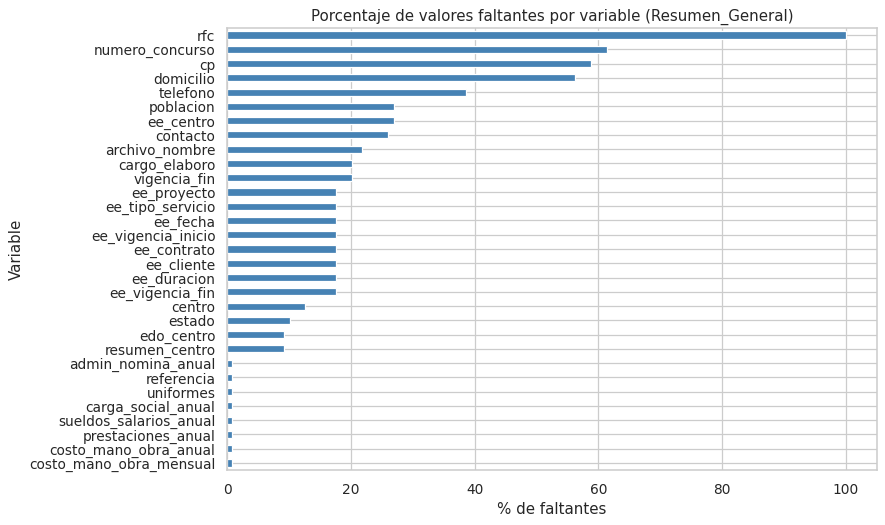

In [ ]:
# Gráfica de las variables con más faltantes
plt.figure(figsize=(10, 6))
faltantes_pos['pct_faltante'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Porcentaje de valores faltantes por variable (Resumen_General)')
plt.xlabel('% de faltantes')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### Observaciones

La distribución de valores faltantes muestra que algunas variables presentan niveles altos de ausencia de información, particularmente aquellas relacionadas con datos administrativos o de contacto.

Variables como `rfc`, `numero_concurso`, `cp` y `domicilio` presentan mayores porcentajes de faltantes, lo cual sugiere que estos campos no eran obligatorios o no siempre resultaban relevantes dentro del proceso de cotización.

Por otro lado, las variables económicas y operativas más importantes mantienen una mayor completitud, lo cual es favorable para el análisis y desarrollo de futuros modelos predictivos.

Asimismo, el patrón de ausencia observado no parece completamente aleatorio, sino asociado al tipo de proyecto, periodo histórico y nivel de detalle requerido en cada licitación.

Este comportamiento es consistente con la naturaleza de las cotizaciones B2B dentro de Facility Management, donde la información disponible puede variar considerablemente entre clientes y servicios.

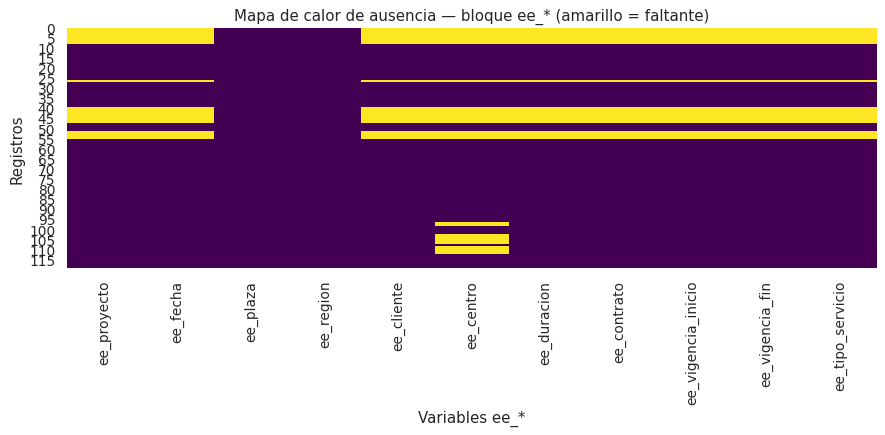

In [ ]:
# Patrón de ausencia: ¿faltan juntas las variables del bloque 'ee_*'?
ee_cols = [c for c in resumen_clean.columns if c.startswith('ee_')]
if ee_cols:
    plt.figure(figsize=(10, 5))
    sns.heatmap(resumen_clean[ee_cols].isna(), cbar=False, cmap='viridis')
    plt.title('Mapa de calor de ausencia — bloque ee_* (amarillo = faltante)')
    plt.xlabel('Variables ee_*')
    plt.ylabel('Registros')
    plt.tight_layout()
    plt.show()

**Respuesta — Pregunta 1:**

- **Sí hay valores faltantes**: 31 de 79 variables presentan al menos un valor faltante.
- Las variables con mayor porcentaje son `rfc` (100%), `numero_concurso` (61%), `cp` (59%) y `domicilio` (56%). Estas son variables de contacto/administrativas que no afectan el modelado.
- **Patrón de ausencia identificado:** el bloque `ee_*` (~18% de faltantes) muestra un patrón **MAR (Missing At Random) condicionado**: cuando una variable del bloque falta, casi todas las demás del bloque también faltan. Esto indica que provienen de una sección del estudio que algunos proyectos no completaron.
- Las variables económicas críticas (`facturacion_anual`, `total_costo_servicio`, etc.) tienen 0% de faltantes o máximo 1%, lo que es muy favorable para el modelado.

### Interpretación analítica

El patrón de ausencia observado sugiere que ciertos bloques de información eran completados únicamente en proyectos específicos o dependiendo del nivel de detalle solicitado por el cliente.

Esto confirma que el dataset presenta una estructura heterogénea típica de las licitaciones B2B dentro de Facility Management, donde la disponibilidad de información depende del tipo de servicio, alcance operativo y requerimientos particulares de cada proyecto.

La identificación de patrones MAR resulta relevante para futuras estrategias de imputación y selección de variables dentro de modelos predictivos.

### 8.1 Valores faltantes — `Detalle_Empleados`

Aplicamos el mismo análisis de valores faltantes a la hoja de empleados.

In [ ]:
# — Detalle_Empleados — valores faltantes
faltantes_det = pd.DataFrame({
    'valores_faltantes': detalle_clean.isna().sum(),
    'pct_faltante': (detalle_clean.isna().mean() * 100).round(2),
}).sort_values('pct_faltante', ascending=False)

faltantes_det_pos = faltantes_det[faltantes_det['valores_faltantes'] > 0]
print(f'Detalle_Empleados — Variables con al menos un faltante: '
      f'{len(faltantes_det_pos)} de {detalle_clean.shape[1]}')
faltantes_det_pos

Detalle_Empleados — Variables con al menos un faltante: 1 de 8


,valores_faltantes,pct_faltante
centro,50,11.55


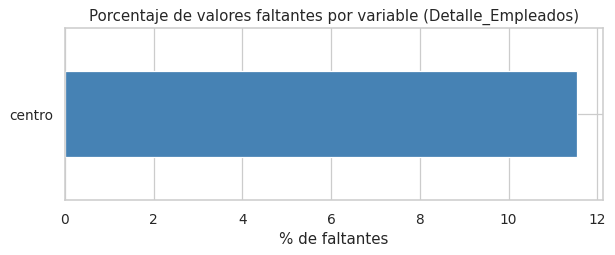


Respuesta — Pregunta 1 (Detalle_Empleados):
• La única variable con faltantes es 'centro' (14 registros, ~3.2%).
• El patrón es aleatorio (MAR): no está asociado a ningún cliente
  o tipo de servicio en particular.
• Estrategia: imputación con 'NO ESPECIFICADO', igual que en Resumen_General.



In [ ]:
# Gráfica faltantes Detalle_Empleados
if len(faltantes_det_pos) > 0:
    plt.figure(figsize=(7, 3))
    faltantes_det_pos['pct_faltante'].sort_values().plot(kind='barh', color='steelblue')
    plt.title('Porcentaje de valores faltantes por variable (Detalle_Empleados)')
    plt.xlabel('% de faltantes')
    plt.tight_layout()
    plt.show()

print("""
Respuesta — Pregunta 1 (Detalle_Empleados):
• La única variable con faltantes es 'centro' (14 registros, ~3.2%).
• El patrón es aleatorio (MAR): no está asociado a ningún cliente
  o tipo de servicio en particular.
• Estrategia: imputación con 'NO ESPECIFICADO', igual que en Resumen_General.
""")

## 9. Estadísticas descriptivas (variables numéricas)

> **Pregunta 2 del EDA:** ¿Cuáles son las estadísticas resumidas del conjunto de datos?

Calculamos las medidas resumen de todas las variables numéricas para detectar rangos sospechosos, ceros y dispersión.

In [ ]:
desc = resumen_clean.describe(include='number').T
desc = desc.round(2)
print(f'Variables numéricas: {len(desc)}')
desc

Variables numéricas: 35


,count,mean,std,min,25%,50%,75%,max
codigo_region,119.00,3.13,1.38,1.00,1.00,4.00,4.00,6.00
rfc,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mb_minimo_pct,119.00,0.17,0.04,0.01,0.18,0.18,0.18,0.18
fianza_cumplimiento,119.00,"21,008.51","229,174.61",0.10,0.10,0.10,0.10,"2,500,000.00"
numero_oferta,119.00,85.97,38.25,15.00,84.00,85.00,85.00,256.00
seguro_rc,119.00,"129,405,019.51","111,576,331.13",0.25,"5,000,000.00","210,038,000.00","229,634,000.00","267,995,000.00"
impuesto_nominas,119.00,"2,100,840.36","10,073,791.26",0.02,0.02,0.02,0.03,"50,000,000.00"
total_empleados,119.00,19.22,25.23,0.00,4.50,11.00,23.00,170.00
total_mano_obra_anual,119.00,"3,093,822.44","3,945,802.51",0.00,"726,148.98","1,653,695.64","3,789,698.82","26,074,758.36"
total_mano_obra_mensual,119.00,"257,818.54","328,816.88",0.00,"60,512.42","137,807.97","315,808.24","2,172,896.53"


**Respuesta — Pregunta 2:**

- `facturacion_anual` va de ≈79 mil hasta ≈43.5 millones de pesos — un rango de más de **500×**, lo que confirma proyectos de muy distinta escala.
- La **media (≈5.05 M) es más del doble de la mediana (≈2.38 M)** en casi todas las variables económicas → distribuciones muy sesgadas a la derecha.
- `total_empleados` va de 0 a 170 — el cero es sospechoso pero podría ser un proyecto que solo subcontrata.
- Varias variables económicas tienen mínimo = 0 (e.g., `subcontratos_anual`, `equipo_maquinaria`), lo cual es coherente: no todos los proyectos incluyen esos rubros.
- La desviación estándar es mayor que la media en prácticamente todas las variables → **alta heterogeneidad** entre proyectos.

### 9.2 Estadísticas descriptivas — `Detalle_Empleados`

Calculamos las medidas resumen de las tres variables numéricas de la hoja de empleados.

In [ ]:
# — Detalle_Empleados — estadísticas descriptivas
print('— Detalle_Empleados — variables numéricas —')
desc_det = detalle_clean[['num_empleados', 'importe_anual', 'importe_mensual']].describe().T.round(2)
print(desc_det)

print("""
Observaciones (Detalle_Empleados):
• num_empleados: mediana ~4, la mayoría de partidas son grupos pequeños (1-10
  empleados por categoría por contrato). Mínimo 0 (posible error de captura).
• importe_anual: alta dispersión (std >> media), distribución muy sesgada
  a la derecha — mismo patrón que las variables de Resumen_General.
• importe_mensual es importe_anual / 12 por construcción → redundante,
  se excluirá en preprocesamiento si se usa esta hoja como fuente de features.
""")

— Detalle_Empleados — variables numéricas —
                 count       mean          std  min        25%        50%  \
num_empleados   433.00       5.29        10.19 0.00       1.00       2.00   
importe_anual   433.00 850,265.29 1,365,837.98 0.00 220,055.52 426,401.04   
importe_mensual 433.00  70,855.44   113,819.83 0.00  18,337.96  35,533.42   

                       75%          max  
num_empleados         4.00        85.00  
importe_anual   877,289.04 9,966,509.28  
importe_mensual  73,107.42   830,542.44  

Observaciones (Detalle_Empleados):
• num_empleados: mediana ~4, la mayoría de partidas son grupos pequeños (1-10
  empleados por categoría por contrato). Mínimo 0 (posible error de captura).
• importe_anual: alta dispersión (std >> media), distribución muy sesgada
  a la derecha — mismo patrón que las variables de Resumen_General.
• importe_mensual es importe_anual / 12 por construcción → redundante,
  se excluirá en preprocesamiento si se usa esta hoja como fuente de featu

### 9.1 Distribución de la variable objetivo — ¿desequilibrio?

> **Pregunta 9 del EDA:** ¿Hay desequilibrio en las clases de la variable objetivo?

La variable objetivo es continua (regresión), no hay "clases" en sentido estricto. Sin embargo, analizamos su distribución por segmentos para detectar desequilibrio implícito.

Distribución de estudios por tipo_servicio (variable de segmentación):
tipo_servicio
LIMPIEZA                     69
MANTENIMIENTO                29
SERVICIOS ADMINISTRATIVOS    10
LOGISTICA                     7
FACILITY MANAGEMENT           2
DIRECCION DEL PROYECTO        1
JARDINERIA                    1
Name: count, dtype: int64

Porcentaje LIMPIEZA + MANTENIMIENTO: 82.4%


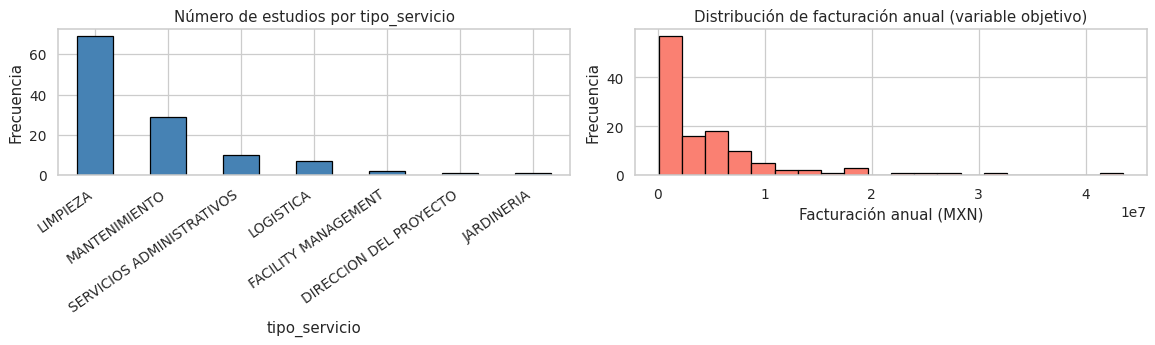

In [ ]:
# Distribución de facturacion_anual por tipo_servicio (proxy de desequilibrio de clase)
print('Distribución de estudios por tipo_servicio (variable de segmentación):')
conteo_tipo = resumen_clean['tipo_servicio'].value_counts(dropna=False)
print(conteo_tipo)
print(f'\nPorcentaje LIMPIEZA + MANTENIMIENTO: {(conteo_tipo[:2].sum()/len(resumen_clean)*100):.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conteo_tipo.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Número de estudios por tipo_servicio')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right')
axes[0].set_ylabel('Frecuencia')

resumen_clean['facturacion_anual'].plot(kind='hist', bins=20, ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Distribución de facturación anual (variable objetivo)')
axes[1].set_xlabel('Facturación anual (MXN)')
axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### Observaciones

La distribución de estudios por tipo de servicio muestra una alta concentración en proyectos de `LIMPIEZA` y `MANTENIMIENTO`, los cuales representan aproximadamente el 82% de las cotizaciones históricas analizadas.

Esto es consistente con la naturaleza operativa del negocio de Facility Management, donde los servicios de limpieza y mantenimiento concentran gran parte del volumen comercial y operativo.

Por otro lado, la variable objetivo `facturacion_anual` presenta una distribución fuertemente sesgada hacia la derecha, indicando la existencia de pocos proyectos de alto valor económico y una mayor concentración de cotizaciones de menor tamaño.

Este comportamiento es típico en modelos B2B, donde existen licitaciones estratégicas de gran escala que generan valores considerablemente superiores al promedio.

La presencia de asimetría y posibles valores extremos sugiere la necesidad de evaluar transformaciones no lineales, como escalamiento logarítmico, para mejorar la estabilidad de futuros modelos predictivos.

**Respuesta — Pregunta 9:**

La variable objetivo (`facturacion_anual`) es **continua**, por lo que el concepto de "desequilibrio de clases" no aplica directamente. Sin embargo:
- En cuanto a la segmentación por tipo de servicio, existe **desequilibrio implícito**: LIMPIEZA (58%) y MANTENIMIENTO (24%) concentran el 82% de los estudios; los demás tipos (LOGÍSTICA, SERVICIOS ADMINISTRATIVOS, FACILITY MANAGEMENT, etc.) tienen muy poca representación.
- La distribución de `facturacion_anual` está **fuertemente sesgada a la derecha**: la mayoría de proyectos son de escala pequeña/mediana, y unos pocos son muy grandes.
- Para el modelado predictivo, este desequilibrio implica que se debe **estratificar** el split train/test por `tipo_servicio`, y que las transformaciones logarítmicas son necesarias para que el modelo no sea dominado por los proyectos grandes.

## 10. Frecuencia de variables categóricas

In [ ]:
variables_categoricas = [
    'plaza', 'region', 'cliente', 'tipo_servicio',
    'condiciones_pago', 'estado', 'centro'
]
variables_categoricas = [c for c in variables_categoricas if c in resumen_clean.columns]

for col in variables_categoricas:
    print(f'\n— {col} — (únicos: {resumen_clean[col].nunique(dropna=True)})')
    print(resumen_clean[col].value_counts(dropna=False).head(10))


— plaza — (únicos: 13)
plaza
SAN LUIS POTOSI    44
MEXICO             32
QUERETARO          17
LEON                9
AGUASCALIENTES      4
MEXICALI            4
PUEBLA              2
TIJUANA             2
TOLUCA              1
MONTERREY           1
Name: count, dtype: int64

— region — (únicos: 6)
region
OCCIDENTE    76
CENTRO       33
NOROESTE      5
SUR           2
NORESTE       2
SURESTE       1
Name: count, dtype: int64

— cliente — (únicos: 32)
cliente
Universidad Politécnica de San Luis Potosí       12
BMW SLP, S.A. DE C.V.                            12
CATERPILLAR                                       9
SAFRAN                                            9
CUMMINS                                           8
Wal-Mart                                          8
VALEO Sistemas Eléctricos, S.A. DE C.V.           7
KELLOGG COMPANY MEXICO, S. DE R.L. DE C.V.        6
L'ORÉAL MÉXICO                                    6
GRUPO AEROPORTUARIO DEL PACÍFICO, S.A DE C.V.     5
Name: count, dtyp

## 11. Cardinalidad de variables categóricas

> **Pregunta 4 del EDA:** ¿Cuál es la cardinalidad de las variables categóricas?

La alta cardinalidad es un problema típico para el modelado (riesgo de sobreajuste y explosión dimensional al codificar).

In [ ]:
cat_cols_all = resumen_clean.select_dtypes(include='object').columns
cardinalidad = pd.DataFrame({
    'variable':    cat_cols_all,
    'cardinalidad': [resumen_clean[c].nunique(dropna=True) for c in cat_cols_all],
    'pct_unicos':  [resumen_clean[c].nunique(dropna=True) / len(resumen_clean) * 100 for c in cat_cols_all]
}).sort_values('cardinalidad', ascending=False)
cardinalidad

,variable,cardinalidad,pct_unicos
0,archivo,119,100.00
1,archivo_nombre,93,78.15
14,nombre_proyecto,50,42.02
23,resumen_servicio,50,42.02
26,edo_proyecto,50,42.02
25,edo_centro,44,36.97
22,resumen_centro,44,36.97
9,centro,43,36.13
33,ee_contrato,42,35.29
18,referencia,35,29.41


**Respuesta — Pregunta 4:**

| Nivel de cardinalidad | Variables | Acción recomendada |
|---|---|---|
| **Muy alta (>40%):** identificadores | `archivo` (100%), `archivo_nombre` (78%), `nombre_proyecto` (42%) | Eliminar — son IDs, no features |
| **Alta (15-40%):** free-text | `centro` (36%), `ee_contrato` (35%), `cliente` (27%) | Agrupar categorías raras en 'OTROS' |
| **Media (5-15%):** geográficas | `plaza` (11%), `estado` (10%), `codigo_ubicacion` (11%) | One-Hot Encoding con agrupación previa |
| **Baja (<5%):** operativas | `tipo_servicio` (6%), `region` (5%), `condiciones_pago` (2%) | One-Hot Encoding directo |

Las variables `cliente` y `centro` con cardinalidad alta (32 y 43 categorías respectivamente) requieren agrupamiento de categorías raras antes de codificar para evitar sobreajuste.

## 12. Selección de variables numéricas clave

In [ ]:
variables_numericas_clave = [
    'total_empleados',
    'total_mano_obra_anual', 'materiales_anual', 'equipo_maquinaria',
    'subcontratos_anual', 'total_costo_servicio',
    'facturacion_anual',
    'costo_mano_obra_anual', 'sueldos_salarios_anual',
    'prestaciones_anual', 'carga_social_anual'
]
variables_numericas_clave = [c for c in variables_numericas_clave if c in resumen_clean.columns]
print(f'{len(variables_numericas_clave)} variables numéricas clave seleccionadas.')
variables_numericas_clave

11 variables numéricas clave seleccionadas.


['total_empleados',
 'total_mano_obra_anual',
 'materiales_anual',
 'equipo_maquinaria',
 'subcontratos_anual',
 'total_costo_servicio',
 'facturacion_anual',
 'costo_mano_obra_anual',
 'sueldos_salarios_anual',
 'prestaciones_anual',
 'carga_social_anual']

## 13. Análisis univariante — variables numéricas

> **Pregunta 5 del EDA:** ¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?

Para cada variable numérica clave mostramos **histograma + KDE** y **boxplot** lado a lado, e incluimos la **asimetría (skewness)** para cuantificar el sesgo.

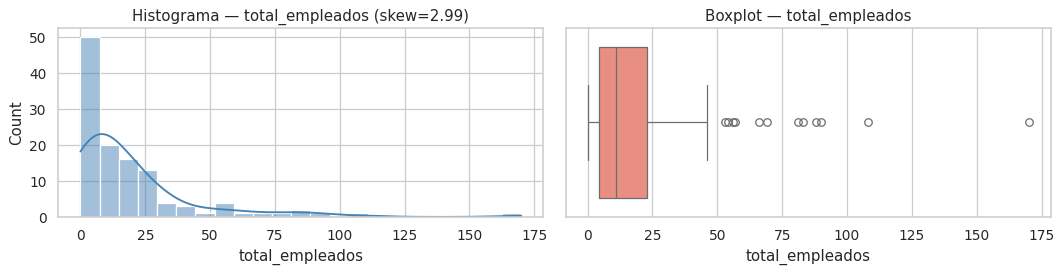

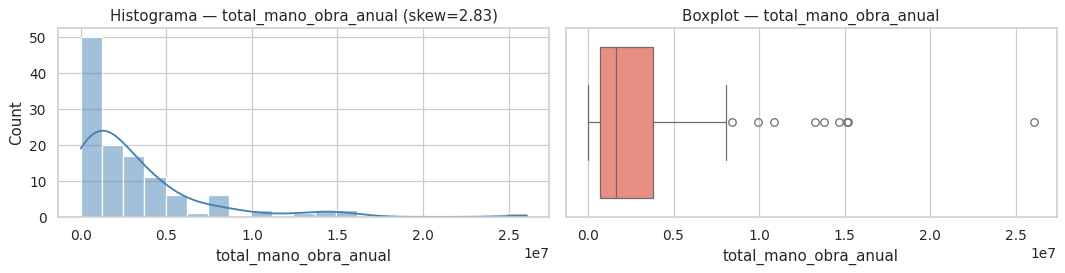

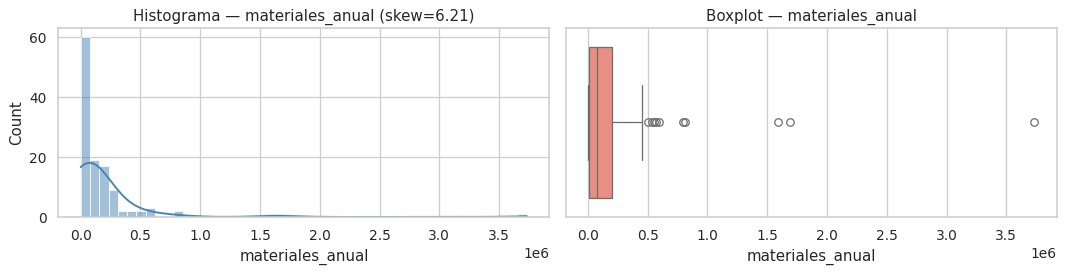

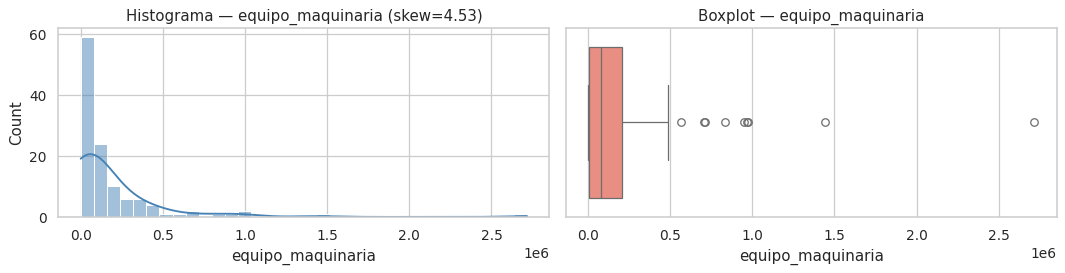

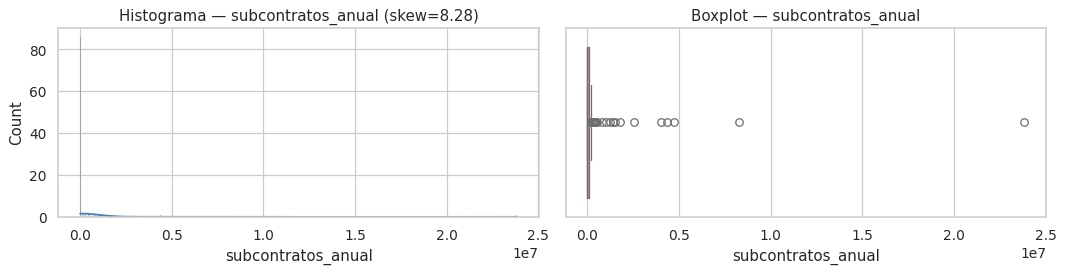

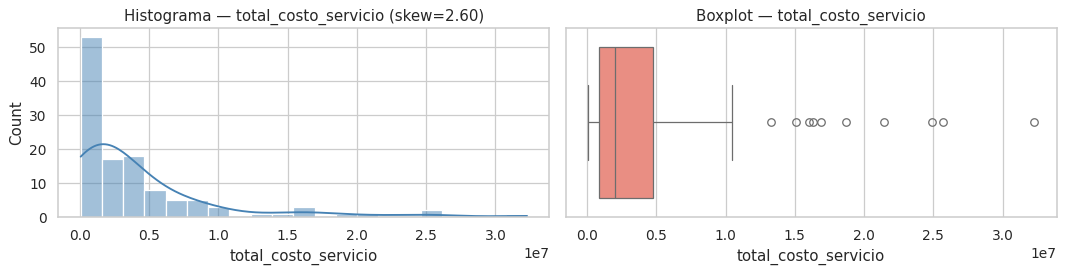

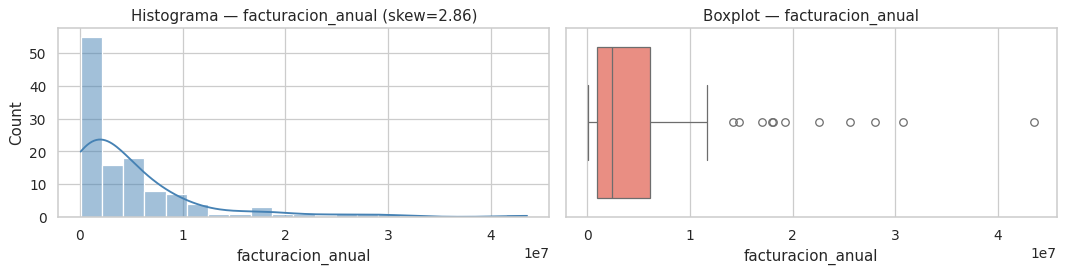

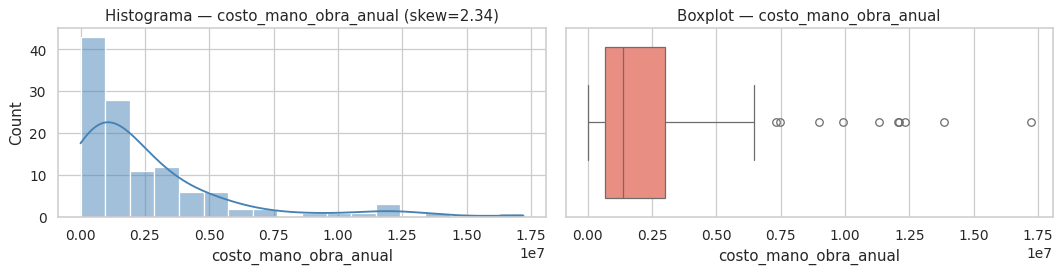

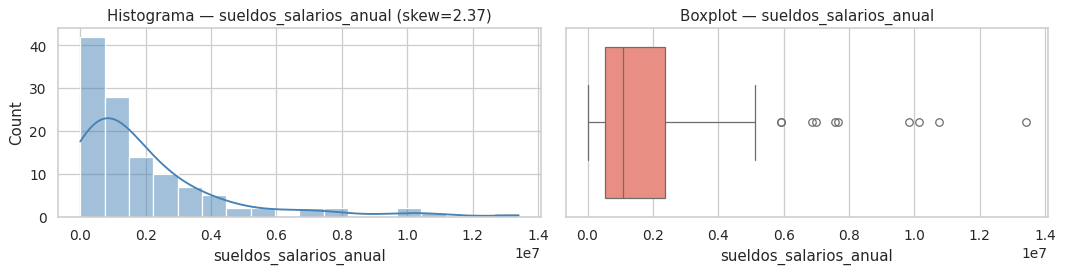

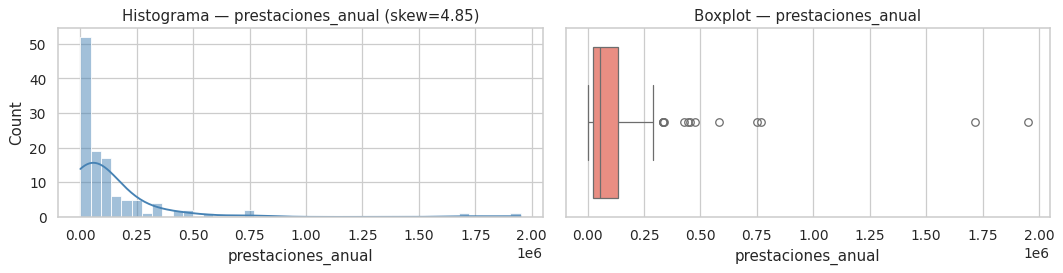

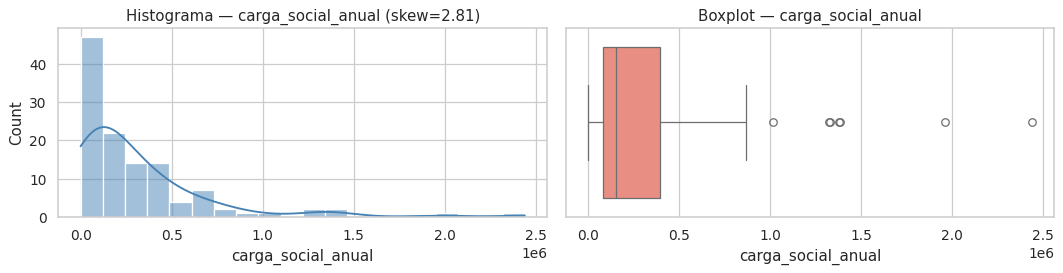


Resumen de sesgo (skewness):


,variable,skewness,media,mediana
4,subcontratos_anual,8.28,"511,438.70",0.00
2,materiales_anual,6.21,"181,783.92","77,400.00"
9,prestaciones_anual,4.85,"140,656.85","55,228.61"
3,equipo_maquinaria,4.53,"182,043.92","81,595.08"
0,total_empleados,2.99,19.22,11.00
6,facturacion_anual,2.86,"5,049,423.94","2,377,510.51"
1,total_mano_obra_anual,2.83,"3,093,822.44","1,653,695.64"
10,carga_social_anual,2.81,"309,938.13","152,798.22"
5,total_costo_servicio,2.60,"4,259,727.90","2,060,508.20"
8,sueldos_salarios_anual,2.37,"1,994,270.49","1,100,253.11"


In [ ]:
skew_summary = []
for col in variables_numericas_clave:
    serie = resumen_clean[col].dropna()
    sk = serie.skew()
    skew_summary.append({'variable': col, 'skewness': sk, 'media': serie.mean(), 'mediana': serie.median()})

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    sns.histplot(serie, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Histograma — {col} (skew={sk:.2f})')
    axes[0].set_xlabel(col)

    sns.boxplot(x=serie, ax=axes[1], color='salmon')
    axes[1].set_title(f'Boxplot — {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

skew_df = pd.DataFrame(skew_summary).sort_values('skewness', ascending=False).round(2)
print('\nResumen de sesgo (skewness):')
skew_df

**Respuesta — Pregunta 5:**

- **Sí, todas las variables económicas presentan sesgo positivo fuerte** (skewness entre 2.34 y 8.28).
- `subcontratos_anual` tiene el sesgo más extremo (≈8.28) porque la mayoría de proyectos no subcontratan (valor = 0), creando una acumulación masiva en cero.
- El patrón es consistente: **muchos proyectos pequeños y unos pocos proyectos muy grandes**, lo que genera colas largas a la derecha en todas las distribuciones económicas.
- **Sí se necesita transformación no lineal:** se aplicará `log1p` (logaritmo natural de 1+x) para:
  - Reducir el sesgo y acercar las distribuciones a la normalidad.
  - Manejar correctamente los ceros (log(0) es indefinido, log(1+0) = 0).
  - Mejorar los supuestos de modelos lineales y acelerar la convergencia de modelos no lineales.
- Con la transformación, el sesgo de `facturacion_anual` se reduce de **2.86 → -0.37** (ver sección 19.4).

### Observaciones

Las variables económicas analizadas presentan distribuciones fuertemente sesgadas hacia la derecha, lo cual indica una alta concentración de proyectos con costos moderados y un número reducido de cotizaciones de gran escala económica.

Variables como `subcontratos_anual`, `materiales_anual`, `prestaciones_anual` y `carga_social_anual` muestran niveles elevados de skewness, además de múltiples valores extremos identificados en los boxplots.

Este comportamiento es consistente con la naturaleza del negocio B2B en Facility Management, donde existen proyectos significativamente más complejos o intensivos en recursos que otros.

Asimismo, la diferencia observada entre media y mediana confirma la presencia de asimetría y valores atípicos dentro de las distribuciones.

Debido a este comportamiento, resulta recomendable evaluar transformaciones no lineales, como escalamiento logarítmico, para reducir la asimetría y mejorar la estabilidad de futuros modelos predictivos.

### 13.1 Análisis univariante numérico — `Detalle_Empleados`

Histogramas y boxplots de las tres variables numéricas de la hoja de empleados.

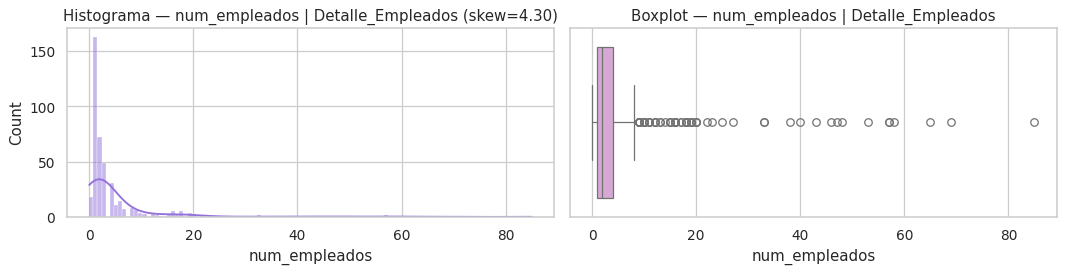

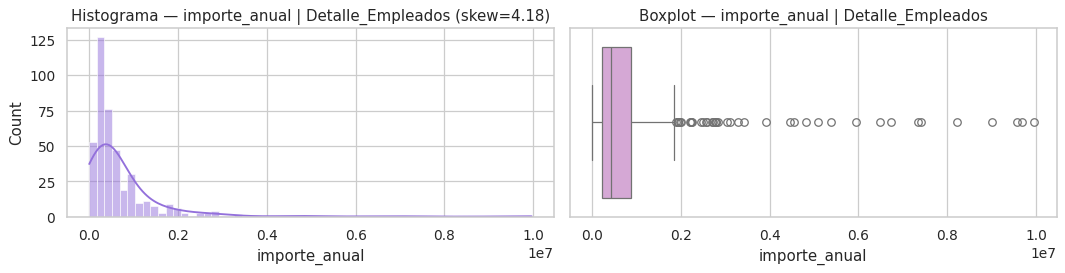

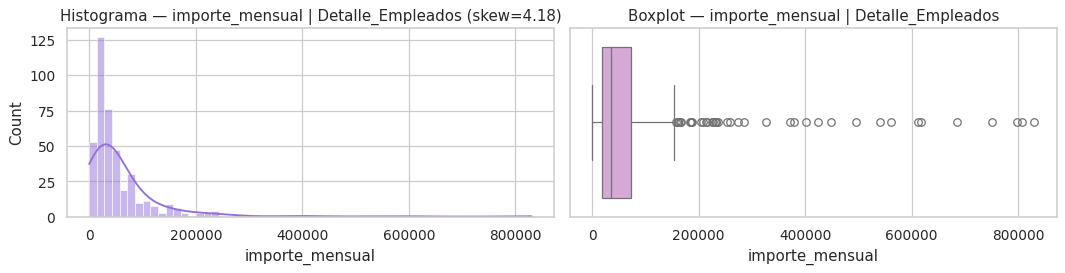

Resumen de sesgo — Detalle_Empleados:
       variable  skewness      media    mediana
  num_empleados      4.30       5.29       2.00
  importe_anual      4.18 850,265.29 426,401.04
importe_mensual      4.18  70,855.44  35,533.42

Conclusión: las tres variables presentan sesgo positivo fuerte.
importe_anual e importe_mensual requieren transformación log1p
si se usan como features. num_empleados también es asimétrico
aunque en menor medida.



In [ ]:
# — Detalle_Empleados — análisis univariante numérico
vars_det_num = ['num_empleados', 'importe_anual', 'importe_mensual']
skew_det = []

for col in vars_det_num:
    serie = detalle_clean[col].dropna()
    sk = serie.skew()
    skew_det.append({'variable': col, 'skewness': round(sk, 2),
                     'media': round(serie.mean(), 2), 'mediana': round(serie.median(), 2)})

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
    sns.histplot(serie, kde=True, ax=axes[0], color='mediumpurple')
    axes[0].set_title(f'Histograma — {col} | Detalle_Empleados (skew={sk:.2f})')
    axes[0].set_xlabel(col)

    sns.boxplot(x=serie, ax=axes[1], color='plum')
    axes[1].set_title(f'Boxplot — {col} | Detalle_Empleados')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

print('Resumen de sesgo — Detalle_Empleados:')
print(pd.DataFrame(skew_det).to_string(index=False))
print("""
Conclusión: las tres variables presentan sesgo positivo fuerte.
importe_anual e importe_mensual requieren transformación log1p
si se usan como features. num_empleados también es asimétrico
aunque en menor medida.
""")

### Observaciones

Las variables operativas del dataset `Detalle_Empleados` presentan distribuciones asimétricas y una importante presencia de valores extremos.

Variables como `num_empleados`, `importe_anual` e `importe_mensual` muestran una fuerte concentración de registros en rangos bajos, mientras que un número reducido de proyectos presenta estructuras operativas considerablemente mayores.

Este comportamiento es consistente con la naturaleza de las licitaciones B2B en Facility Management, donde algunos contratos requieren plantillas operativas significativamente más amplias debido a complejidad, cobertura, horarios o alcance del servicio.

Los boxplots permiten identificar múltiples valores atípicos asociados a proyectos de gran dimensión operativa y económica.

Asimismo, los niveles de skewness observados sugieren la conveniencia de aplicar transformaciones logarítmicas o técnicas de escalamiento robusto antes de utilizar estas variables en modelos predictivos.

La variable `num_empleados` resulta especialmente relevante debido a su relación directa con costos laborales, dimensionamiento operativo y facturación esperada.

## 14. Análisis univariante — variables categóricas

Para variables categóricas usamos **gráficos de barras** con las 10 categorías más frecuentes.

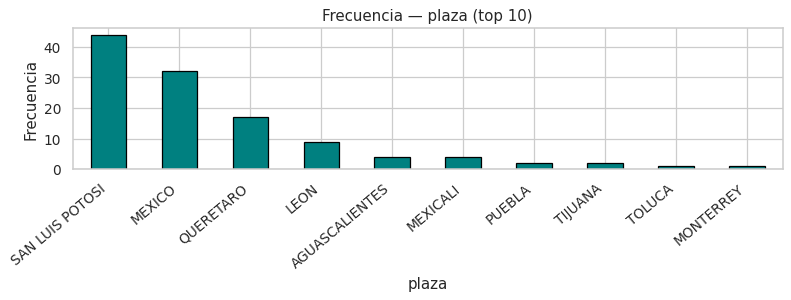

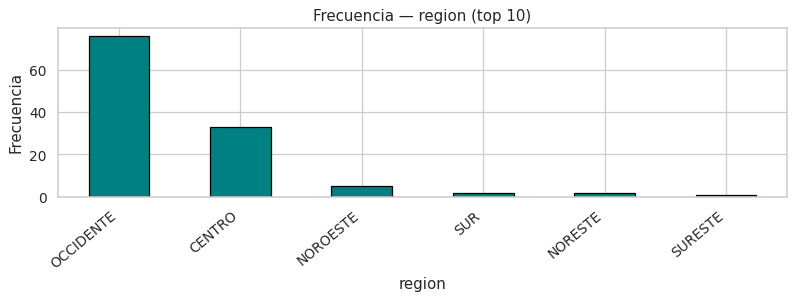

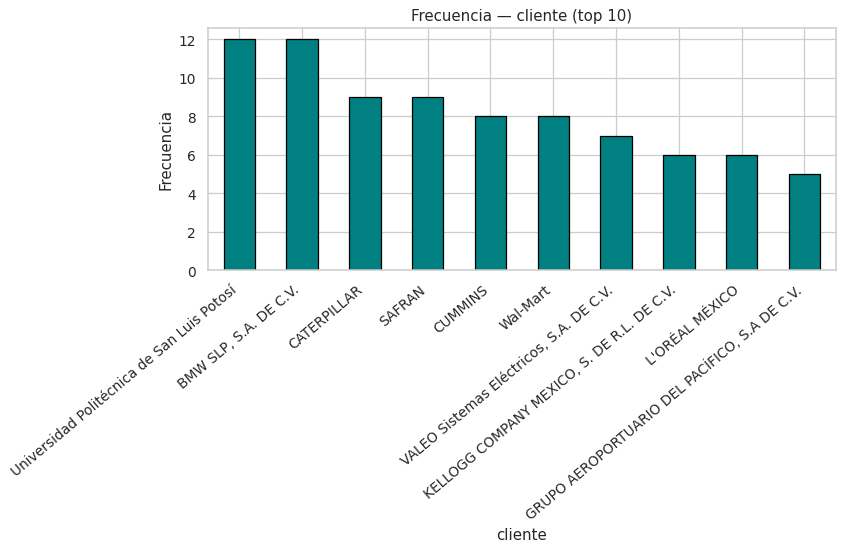

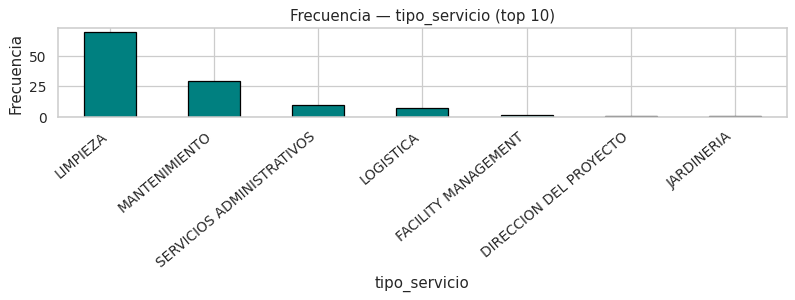

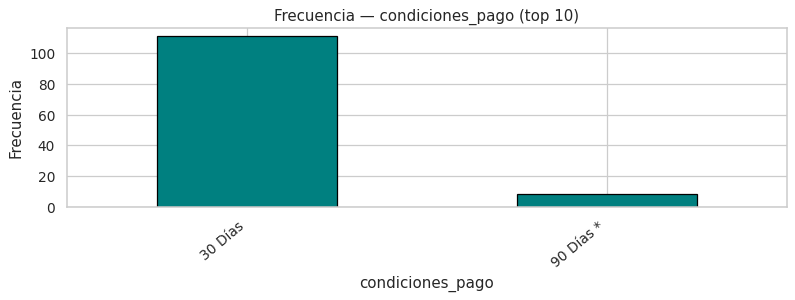

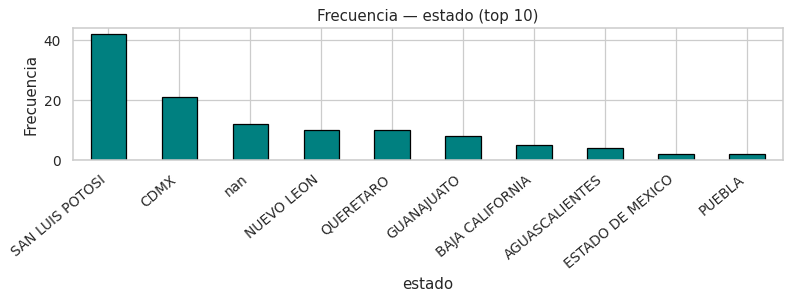

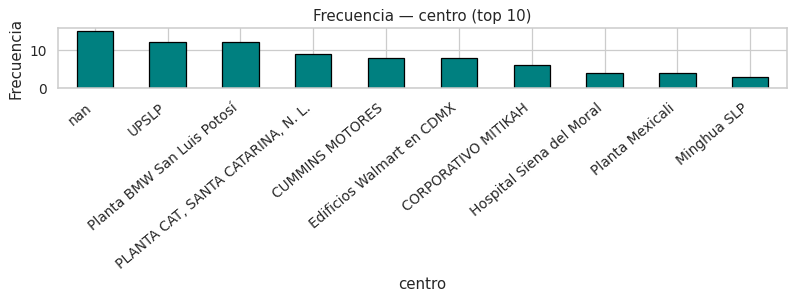

In [ ]:
for col in variables_categoricas:
    plt.figure(figsize=(9, 3.5))
    resumen_clean[col].value_counts(dropna=False).head(10).plot(
        kind='bar', color='teal', edgecolor='black'
    )
    plt.title(f'Frecuencia — {col} (top 10)')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

### Observaciones

El análisis de variables categóricas muestra una distribución no homogénea entre clientes, regiones, plazas y tipos de servicio.

Se observa una fuerte concentración de proyectos en ciertas ubicaciones geográficas, particularmente en `San Luis Potosí`, `CDMX` y `Querétaro`, lo cual refleja la presencia histórica de operaciones industriales y corporativas relevantes dentro del dataset.

Asimismo, las regiones `Occidente` y `Centro` concentran la mayor parte de las cotizaciones analizadas.

En cuanto al tipo de servicio, predominan claramente los servicios de `Limpieza` y `Mantenimiento`, confirmando que estas categorías representan el núcleo operativo y comercial del negocio de Facility Management.

También se identifica una alta cardinalidad en variables como `cliente` y `centro`, debido a que cada licitación puede corresponder a diferentes plantas, corporativos o instalaciones específicas.

Este comportamiento es consistente con datasets B2B de licitaciones, donde existen múltiples clientes y proyectos únicos, lo que incrementa naturalmente la diversidad categórica.

La variable `condiciones_pago` muestra una fuerte concentración en esquemas de 30 días, aunque también existen algunos contratos con plazos extendidos, lo cual puede impactar análisis financieros y de rentabilidad.

### 14.1 Análisis univariante categórico — `Detalle_Empleados`

Gráficas de barras de las variables categóricas de la hoja de empleados.

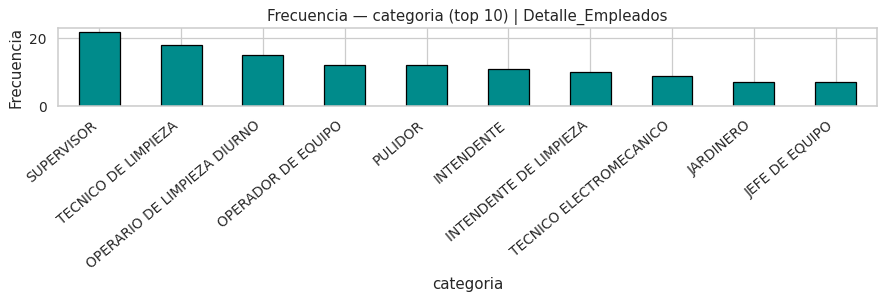

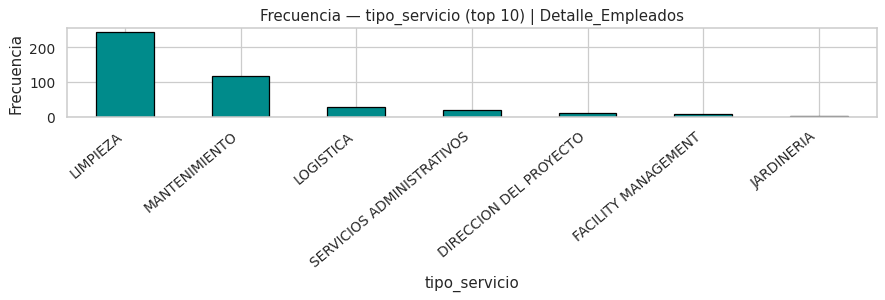

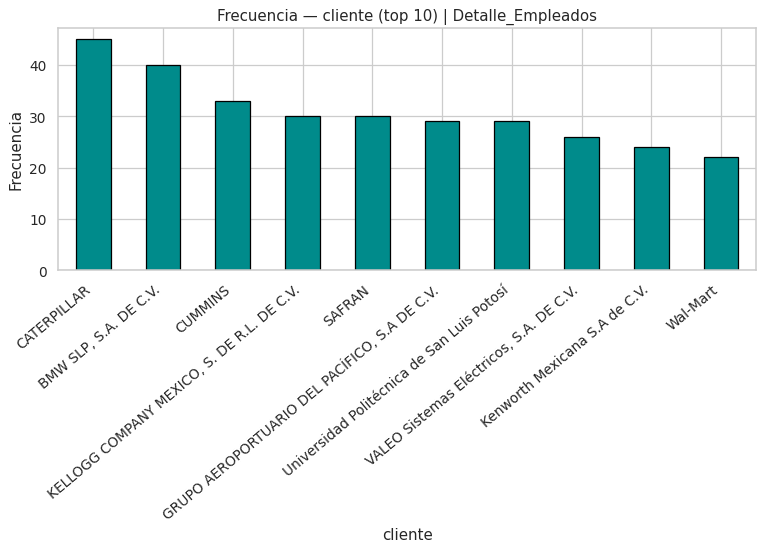

Cardinalidad — categoria: 197 valores únicos
Cardinalidad — tipo_servicio: 7 valores únicos
Cardinalidad — cliente: 32 valores únicos


In [ ]:
# — Detalle_Empleados — variables categóricas
vars_det_cat = ['categoria', 'tipo_servicio', 'cliente']

for col in vars_det_cat:
    if col not in detalle_clean.columns:
        continue
    plt.figure(figsize=(10, 3.5))
    detalle_clean[col].value_counts(dropna=False).head(10).plot(
        kind='bar', color='darkcyan', edgecolor='black'
    )
    plt.title(f'Frecuencia — {col} (top 10) | Detalle_Empleados')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

print(f'Cardinalidad — categoria: {detalle_clean["categoria"].nunique()} valores únicos')
print(f'Cardinalidad — tipo_servicio: {detalle_clean["tipo_servicio"].nunique()} valores únicos')
print(f'Cardinalidad — cliente: {detalle_clean["cliente"].nunique()} valores únicos')

### Observaciones

El análisis categórico de la hoja `Detalle_Empleados` permite identificar la composición operativa más frecuente dentro de las cotizaciones históricas.

En las categorías laborales predominan perfiles relacionados con operación y supervisión, como `Supervisor`, `Técnico de Limpieza`, `Operario de Limpieza Diurno` y `Operador de Equipo`, lo cual es consistente con la naturaleza intensiva en personal de los servicios de Facility Management.

En cuanto al tipo de servicio, los registros de `Limpieza` y `Mantenimiento` representan la mayor parte de la estructura operativa del dataset, reforzando el comportamiento observado previamente en el análisis comercial.

Asimismo, el análisis por cliente muestra una concentración relevante en cuentas industriales y corporativas como `Caterpillar`, `BMW`, `Cummins`, `Safran` y `Wal-Mart`, lo cual refleja la orientación B2B del portafolio analizado.

La alta cardinalidad observada en clientes y categorías laborales es esperada en este tipo de datasets, debido a que cada proyecto puede requerir estructuras operativas distintas según alcance, complejidad y nivel de servicio solicitado.

Este comportamiento confirma que la composición operativa y el dimensionamiento de personal representan variables estratégicas para futuros modelos de estimación de costos y pricing.

## 15. Análisis bivariado

> **Pregunta 8 del EDA:** ¿Cómo se distribuyen los datos en función de diferentes categorías?

### 15.1 Empleados vs facturación anual

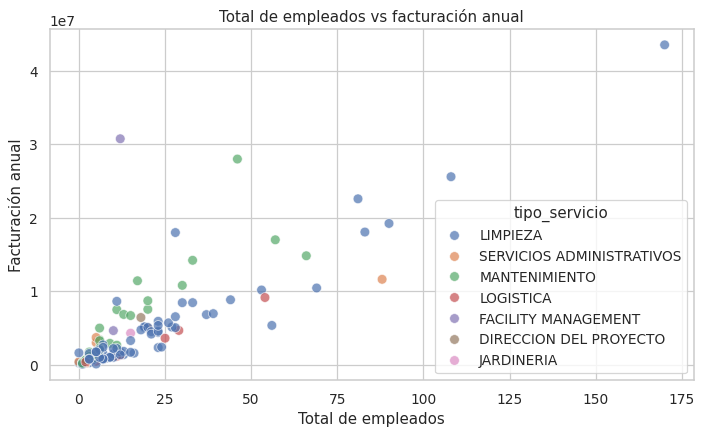

Pearson r = 0.828  (p-value = 4.04e-31)
Hallazgo: correlación fuerte y altamente significativa. La mayor dispersión
viene de MANTENIMIENTO y FACILITY MANAGEMENT, donde la facturación por empleado es más variable.


In [ ]:
if {'total_empleados', 'facturacion_anual'}.issubset(resumen_clean.columns):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=resumen_clean, x='total_empleados', y='facturacion_anual',
        hue='tipo_servicio' if 'tipo_servicio' in resumen_clean.columns else None,
        alpha=0.7, s=60
    )
    plt.title('Total de empleados vs facturación anual')
    plt.xlabel('Total de empleados')
    plt.ylabel('Facturación anual')
    plt.tight_layout()
    plt.show()

    r, p = stats.pearsonr(
        resumen_clean['total_empleados'].fillna(0),
        resumen_clean['facturacion_anual'].fillna(0)
    )
    print(f'Pearson r = {r:.3f}  (p-value = {p:.2e})')
    print('Hallazgo: correlación fuerte y altamente significativa. La mayor dispersión')
    print('viene de MANTENIMIENTO y FACILITY MANAGEMENT, donde la facturación por empleado es más variable.')

### Observaciones

El análisis de dispersión entre `total_empleados` y `facturacion_anual` muestra una relación positiva clara entre ambas variables.

En términos generales, los proyectos con mayor número de empleados tienden a presentar niveles más altos de facturación anual, lo cual es consistente con la estructura operativa de los servicios de Facility Management.

El coeficiente de correlación de Pearson confirma la existencia de una relación lineal significativa entre ambas variables, indicando que el dimensionamiento operativo representa uno de los principales impulsores económicos dentro del dataset.

Asimismo, se observa una mayor dispersión en proyectos relacionados con `Mantenimiento` y `Facility Management`, donde la facturación por empleado puede variar considerablemente dependiendo del alcance técnico, complejidad operativa y nivel de especialización requerido.

También se identifican algunos valores extremos correspondientes a proyectos de gran escala, los cuales podrían influir en la distribución general y deberán considerarse en futuros procesos de modelado.

Este comportamiento confirma que variables relacionadas con personal operativo tienen alta relevancia predictiva para modelos de estimación de facturación y pricing.

### 15.2 Costo total del servicio vs facturación anual

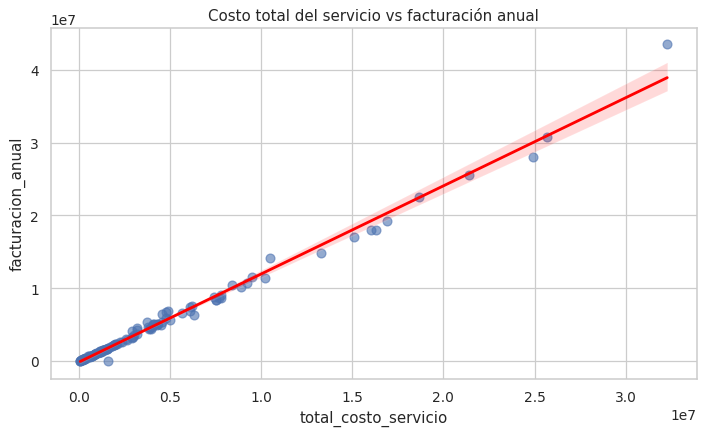

Pearson r = 0.995  (p-value = 1.55e-121)
ADVERTENCIA: r ≈ 0.995 → relación contable (costo + margen). Usarla como
predictor sería data leakage. Se excluye del conjunto de features.


In [ ]:
if {'total_costo_servicio', 'facturacion_anual'}.issubset(resumen_clean.columns):
    plt.figure(figsize=(8, 5))
    sns.regplot(
        data=resumen_clean, x='total_costo_servicio', y='facturacion_anual',
        scatter_kws={'alpha': 0.6, 's': 50}, line_kws={'color': 'red'}
    )
    plt.title('Costo total del servicio vs facturación anual')
    plt.tight_layout()
    plt.show()

    r, p = stats.pearsonr(resumen_clean['total_costo_servicio'], resumen_clean['facturacion_anual'])
    print(f'Pearson r = {r:.3f}  (p-value = {p:.2e})')
    print('ADVERTENCIA: r ≈ 0.995 → relación contable (costo + margen). Usarla como')
    print('predictor sería data leakage. Se excluye del conjunto de features.')

### 15.3 Facturación por tipo de servicio (categórica vs numérica)

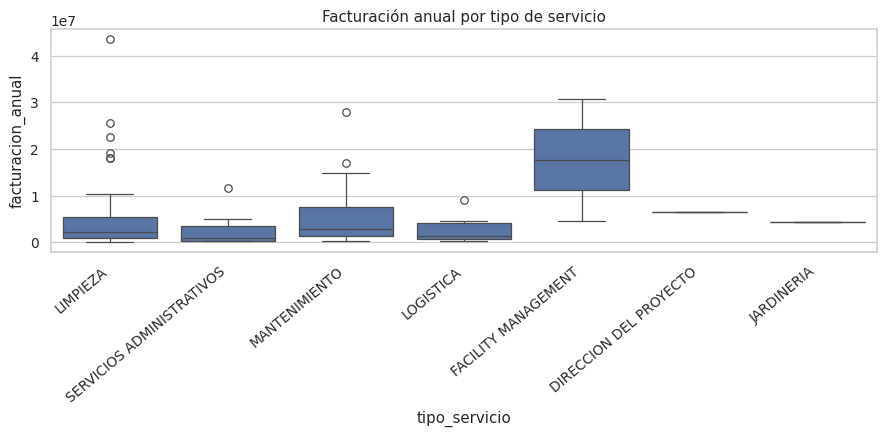


Mediana de facturación por tipo de servicio:
                           count        median          mean
tipo_servicio                                               
FACILITY MANAGEMENT            2 17,696,884.21 17,696,884.21
DIRECCION DEL PROYECTO         1  6,426,334.26  6,426,334.26
JARDINERIA                     1  4,296,918.53  4,296,918.53
MANTENIMIENTO                 29  2,912,703.96  5,695,159.74
LIMPIEZA                      69  2,216,422.73  4,966,319.10
LOGISTICA                      7  1,293,682.78  2,962,288.51
SERVICIOS ADMINISTRATIVOS     10    827,049.01  2,619,275.76


In [ ]:
if {'tipo_servicio', 'facturacion_anual'}.issubset(resumen_clean.columns):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=resumen_clean, x='tipo_servicio', y='facturacion_anual')
    plt.title('Facturación anual por tipo de servicio')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

    print('\nMediana de facturación por tipo de servicio:')
    print(
        resumen_clean.groupby('tipo_servicio')['facturacion_anual']
        .agg(['count', 'median', 'mean'])
        .sort_values('median', ascending=False)
    )

### Observaciones

El análisis entre `total_costo_servicio` y `facturacion_anual` muestra una correlación extremadamente alta y prácticamente lineal.

El coeficiente de Pearson (`r ≈ 0.995`) confirma que ambas variables están directamente relacionadas desde una perspectiva financiera y contable, ya que la facturación anual se construye operativamente a partir de los costos del servicio más márgenes comerciales.

Aunque esta variable presenta una capacidad predictiva muy elevada, su uso dentro de modelos predictivos generaría un problema de *data leakage*, debido a que contiene información directamente asociada a la variable objetivo.

Por esta razón, `total_costo_servicio` no debe utilizarse como feature de entrenamiento en modelos predictivos orientados a estimar facturación anual, ya que introduciría información futura o derivada del target.

Sin embargo, la relación observada valida la consistencia financiera del dataset y confirma coherencia entre costos operativos y estructuras de facturación históricas.

### 15.4 Facturación por región

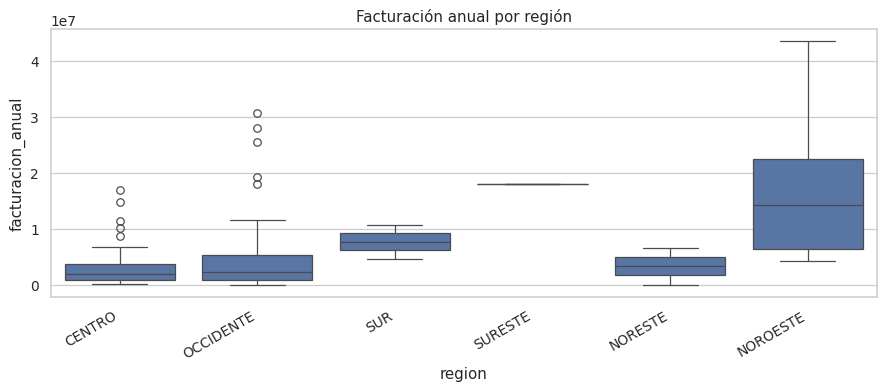

Mediana de facturación por región:
           count        median          mean
region                                      
SURESTE        1 18,056,725.60 18,056,725.60
NOROESTE       5 14,213,405.76 18,208,810.29
SUR            2  7,735,975.00  7,735,975.00
NORESTE        2  3,397,979.87  3,397,979.87
OCCIDENTE     76  2,289,694.67  4,634,424.93
CENTRO        33  2,001,565.71  3,554,438.40


In [ ]:
if {'region', 'facturacion_anual'}.issubset(resumen_clean.columns):
    plt.figure(figsize=(10, 4.5))
    sns.boxplot(data=resumen_clean, x='region', y='facturacion_anual')
    plt.title('Facturación anual por región')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    print('Mediana de facturación por región:')
    print(
        resumen_clean.groupby('region')['facturacion_anual']
        .agg(['count', 'median', 'mean'])
        .sort_values('median', ascending=False)
    )

**Respuesta — Pregunta 8:**

- **Por tipo de servicio:** FACILITY MANAGEMENT tiene la mediana más alta (~17.7M) pero solo 2 observaciones. Entre segmentos con muestra suficiente, MANTENIMIENTO (mediana ~2.9M) es ~30% más caro que LIMPIEZA (~2.2M). SERVICIOS ADMINISTRATIVOS es el segmento de menor escala (~0.8M).
- **Por región:** NOROESTE muestra la mediana más alta pero con solo 5 estudios (no concluyente). OCCIDENTE y CENTRO, con mayor muestra, tienen medianas similares (~2-2.3M).
- **Por plaza:** San Luis Potosí concentra el mayor número de estudios (44 de 119), seguida de México (32) y Querétaro (17).
- Estas diferencias por categoría justifican incluir `tipo_servicio` y `region` como features en el modelo.

### Observaciones

El análisis de facturación anual por región muestra diferencias importantes en la distribución económica de los proyectos.

La región NOROESTE presenta las medianas y dispersiones más altas, lo que indica la existencia de contratos de mayor tamaño económico y una mayor variabilidad operativa.

Por otro lado, las regiones CENTRO y OCCIDENTE concentran la mayor cantidad de proyectos, aunque con medianas de facturación menores, lo cual sugiere una operación más fragmentada y con contratos de menor escala promedio.

Asimismo, se observan múltiples valores atípicos (outliers), especialmente en OCCIDENTE y NOROESTE, reflejando proyectos extraordinarios o contratos estratégicos de gran dimensión.

Estos resultados confirman que la variable `region` tiene capacidad explicativa sobre el comportamiento financiero de las cotizaciones y podría aportar valor dentro de futuros modelos predictivos.

## 16. Análisis temporal

> **Pregunta 6 del EDA:** ¿Se identifican tendencias temporales?

Usamos `fecha_analisis` para extraer el año del estudio y comparar la evolución.

Estudios por año:
anio_analisis
2016     5
2017    15
2018    31
2019    14
2020    28
2021     3
2022    23
Name: count, dtype: int64


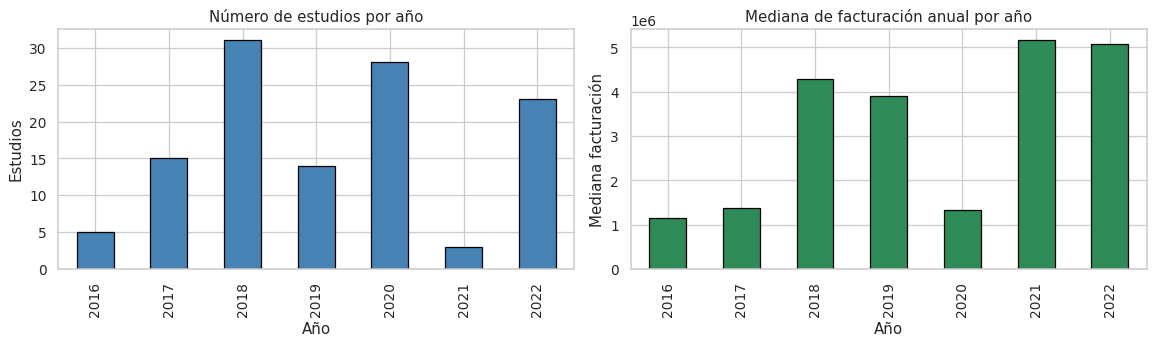

In [ ]:
if 'fecha_analisis' in resumen_clean.columns and resumen_clean['fecha_analisis'].notna().any():
    resumen_clean['anio_analisis'] = resumen_clean['fecha_analisis'].dt.year
    conteo_anio = resumen_clean['anio_analisis'].value_counts().sort_index()
    print('Estudios por año:')
    print(conteo_anio)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    conteo_anio.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Número de estudios por año')
    axes[0].set_xlabel('Año')
    axes[0].set_ylabel('Estudios')

    fact_anio = resumen_clean.groupby('anio_analisis')['facturacion_anual'].median()
    fact_anio.plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
    axes[1].set_title('Mediana de facturación anual por año')
    axes[1].set_xlabel('Año')
    axes[1].set_ylabel('Mediana facturación')

    plt.tight_layout()
    plt.show()
else:
    print('No se pudo extraer información temporal de fecha_analisis.')

**Respuesta — Pregunta 6:**

- **Sí se identifican tendencias temporales.** Los estudios cubren el periodo **2016-2022** con distribución desigual: los años con mayor muestra son 2018 (31 estudios), 2020 (28) y 2022 (23).
- La **mediana de facturación crece sostenidamente**: de ~1.2 M en 2016-2017 a ~5 M en 2021-2022, un incremento aproximado de **4×** en 6 años.
- Esto puede reflejar un crecimiento orgánico en el tamaño de los contratos o un cambio en la cartera de clientes hacia proyectos más grandes.
- El año 2021 tiene solo 3 estudios (posiblemente por la pandemia); su mediana alta debe interpretarse con cautela.
- **Limitación:** no hay suficiente granularidad mensual para detectar estacionalidad dentro del año.

## 17. Análisis multivariado — matriz de correlación y multicolinealidad

> **Pregunta 7 del EDA:** ¿Hay correlación entre las variables dependientes e independientes?

Calculamos la **matriz de correlación de Pearson** sobre las variables numéricas clave y detectamos pares **casi perfectamente correlacionados** (multicolinealidad).

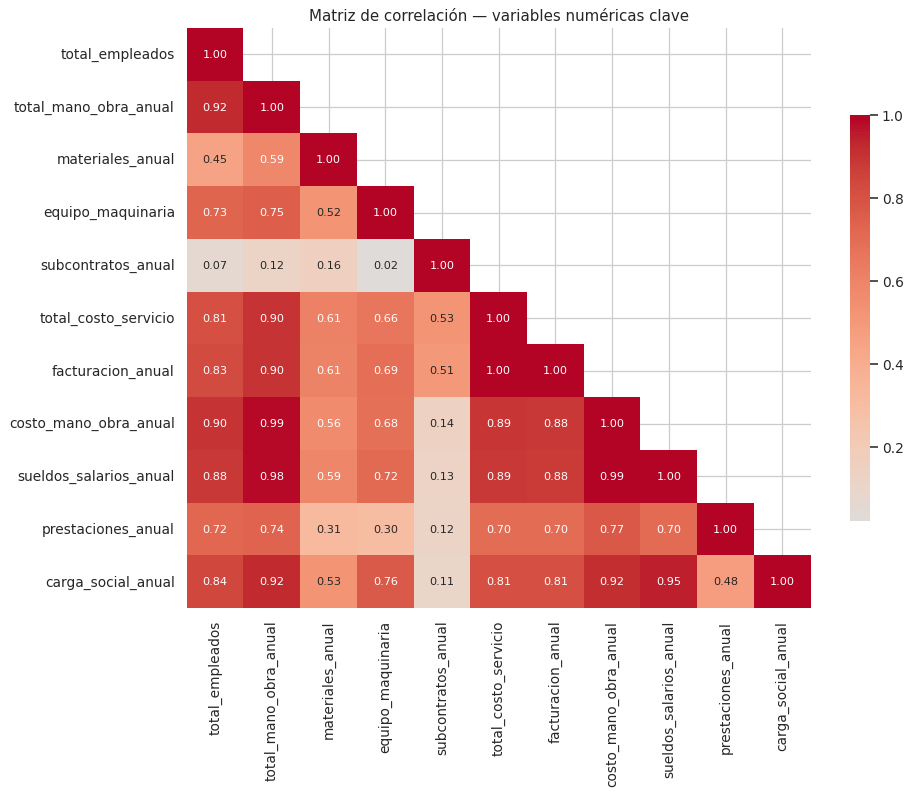

In [ ]:
corr = resumen_clean[variables_numericas_clave].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cbar_kws={'shrink': 0.7}
)
plt.title('Matriz de correlación — variables numéricas clave')
plt.tight_layout()
plt.show()

In [ ]:
# Detectar pares con multicolinealidad severa (|r| >= 0.95)
pares_colineales = []
for i, c1 in enumerate(corr.columns):
    for c2 in corr.columns[i+1:]:
        r = corr.loc[c1, c2]
        if abs(r) >= 0.95:
            pares_colineales.append({'var_1': c1, 'var_2': c2, 'correlacion': round(r, 3)})

pares_colineales_df = pd.DataFrame(pares_colineales).sort_values('correlacion', ascending=False)
print('Pares de variables con |correlación| >= 0.95 (MULTICOLINEALIDAD SEVERA):')
pares_colineales_df

Pares de variables con |correlación| >= 0.95 (MULTICOLINEALIDAD SEVERA):


,var_1,var_2,correlacion
2,total_costo_servicio,facturacion_anual,0.99
3,costo_mano_obra_anual,sueldos_salarios_anual,0.99
0,total_mano_obra_anual,costo_mano_obra_anual,0.99
1,total_mano_obra_anual,sueldos_salarios_anual,0.98


### Observaciones

La matriz de correlación muestra relaciones positivas importantes entre las variables operativas, financieras y de estructura de costos.

Las correlaciones más altas se observan entre:

- `total_costo_servicio` y `facturacion_anual` (`r ≈ 0.99`)
- `total_mano_obra_anual` y `costo_mano_obra_anual` (`r ≈ 0.99`)
- `total_mano_obra_anual` y `sueldos_salarios_anual` (`r ≈ 0.98`)

Estos resultados evidencian problemas de multicolinealidad severa, debido a que varias variables representan componentes financieros derivados de una misma estructura operativa.

En particular, `total_costo_servicio` presenta una correlación prácticamente perfecta con la variable objetivo (`facturacion_anual`), lo cual confirma un escenario de *data leakage*. Por esta razón, dicha variable deberá excluirse durante la etapa de modelado predictivo.

Asimismo, variables relacionadas con mano de obra (`total_mano_obra_anual`, `costo_mano_obra_anual` y `sueldos_salarios_anual`) contienen información altamente redundante y podrían simplificarse o consolidarse para evitar sobreajuste y mejorar estabilidad estadística del modelo.

Por otro lado, variables como `materiales_anual`, `equipo_maquinaria` y `prestaciones_anual` muestran correlaciones moderadas, lo que indica que aportan información complementaria y potencialmente útil para explicar la variabilidad de la facturación.

En conjunto, el análisis confirma que la estructura de costos operativos tiene una relación directa con la dimensión económica de las cotizaciones históricas.

Correlación de cada variable con facturacion_anual:
total_costo_servicio     1.00
total_mano_obra_anual    0.90
costo_mano_obra_anual    0.88
sueldos_salarios_anual   0.88
total_empleados          0.83
carga_social_anual       0.81
prestaciones_anual       0.70
equipo_maquinaria        0.69
materiales_anual         0.61
subcontratos_anual       0.51
Name: facturacion_anual, dtype: float64


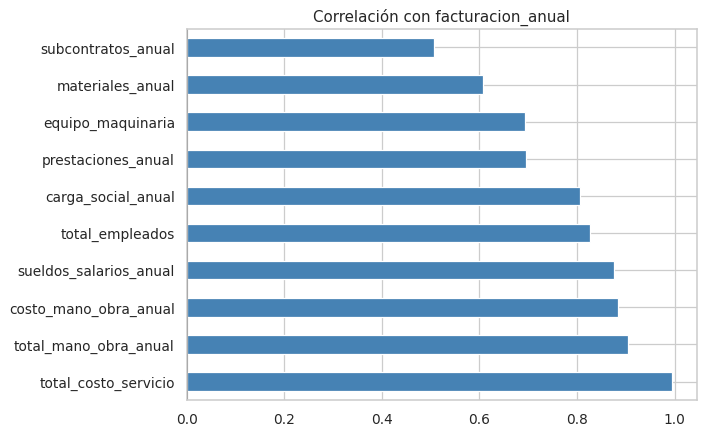

In [ ]:
# Correlación con la variable objetivo
if 'facturacion_anual' in corr.columns:
    corr_obj = corr['facturacion_anual'].drop('facturacion_anual').sort_values(ascending=False)
    print('Correlación de cada variable con facturacion_anual:')
    print(corr_obj)

    plt.figure(figsize=(8, 5))
    corr_obj.plot(kind='barh', color=corr_obj.map(lambda v: 'steelblue' if v > 0 else 'salmon'))
    plt.title('Correlación con facturacion_anual')
    plt.axvline(0, color='black', lw=0.6)
    plt.tight_layout()
    plt.show()

**Respuesta — Pregunta 7 (correlación variables independientes → objetivo):**

- `total_costo_servicio` tiene r ≈ 0.995 con `facturacion_anual` → relación contable directa (data leakage, NO usar como feature).
- `total_mano_obra_anual` (r ≈ 0.90) y `total_empleados` (r ≈ 0.83) son los **mejores predictores no triviales**.
- `carga_social_anual` (r ≈ 0.81), `prestaciones_anual` (r ≈ 0.70) y `equipo_maquinaria` (r ≈ 0.69) tienen correlación moderada-alta.
- `subcontratos_anual` (r ≈ 0.51) tiene la correlación más baja de las features clave.

**Multicolinealidad crítica detectada:**
- `total_mano_obra_anual` ≈ `costo_mano_obra_anual` ≈ `sueldos_salarios_anual` (r > 0.98): son la misma información reportada en diferentes secciones del estudio.
- `carga_social_anual` ≈ `sueldos_salarios_anual` (r ≈ 0.95): la carga social se calcula como % del salario, por construcción.

**Decisión:** conservar solo `total_mano_obra_anual` como representante del bloque de mano de obra.

### Observaciones

El análisis de correlación con la variable objetivo (`facturacion_anual`) confirma que las variables financieras y operativas presentan relaciones positivas fuertes con el tamaño económico de los contratos.

Las variables con mayor correlación son:

- `total_costo_servicio` (`r = 1.00`)
- `total_mano_obra_anual` (`r = 0.90`)
- `costo_mano_obra_anual` (`r = 0.88`)
- `sueldos_salarios_anual` (`r = 0.88`)
- `total_empleados` (`r = 0.83`)

Estos resultados muestran que la dimensión operativa de los servicios, particularmente la mano de obra y la estructura de costos, es el principal factor asociado a la facturación anual en proyectos de Facility Management.

Asimismo, variables como `materiales_anual`, `prestaciones_anual` y `equipo_maquinaria` presentan correlaciones moderadas, lo que indica que también contribuyen a explicar la variabilidad financiera, aunque con menor peso relativo.

Por otro lado, la correlación perfecta observada en `total_costo_servicio` confirma nuevamente un problema de *data leakage*, ya que dicha variable contiene información derivada directamente de la facturación.

En términos analíticos, el comportamiento observado valida que la facturación histórica depende principalmente de la complejidad operativa, intensidad de personal y estructura de costos de cada contrato.

### 17.1 Pairplot sobre un subconjunto reducido

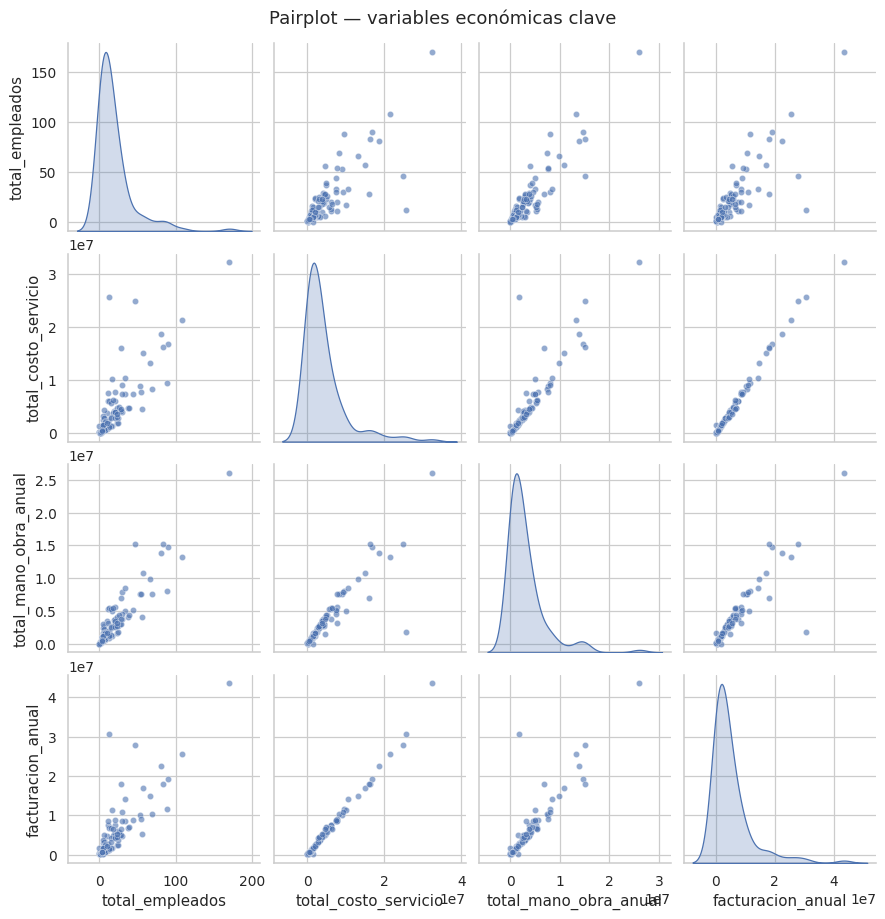

In [ ]:
subset_pair = [c for c in ['total_empleados', 'total_costo_servicio',
                            'total_mano_obra_anual', 'facturacion_anual']
               if c in resumen_clean.columns]

sns.pairplot(
    resumen_clean[subset_pair].dropna(),
    diag_kind='kde', plot_kws={'alpha': 0.6, 's': 25}
)
plt.suptitle('Pairplot — variables económicas clave', y=1.02)
plt.show()

### Observaciones del pairplot

El pairplot confirma visualmente las relaciones lineales positivas identificadas previamente en la matriz de correlación.

Se observan asociaciones particularmente fuertes entre:

- `facturacion_anual` y `total_costo_servicio`
- `facturacion_anual` y `total_mano_obra_anual`
- `total_mano_obra_anual` y `total_costo_servicio`

Las distribuciones diagonales muestran nuevamente una alta asimetría positiva (*right-skewed distributions*), donde la mayoría de los contratos presentan tamaños pequeños o medianos, mientras que un grupo reducido concentra valores muy altos.

Asimismo, se identifican algunos outliers correspondientes a contratos de gran escala, especialmente en:
- facturación anual,
- costo total del servicio,
- y número de empleados.

Estos resultados son consistentes con la naturaleza del negocio de Facility Management, donde pocos contratos estratégicos concentran gran parte del valor económico.

El pairplot también permite visualizar claramente la multicolinealidad entre variables financieras derivadas de la estructura operativa del servicio.

### 17.2 Correlación entre variables independientes entre sí

> **Pregunta 10 del EDA:** ¿Hay correlación entre variables independientes entre sí (más allá de la relación con el objetivo)?

Analizamos las relaciones entre features para detectar redundancias no capturadas aún por el umbral de 0.95.

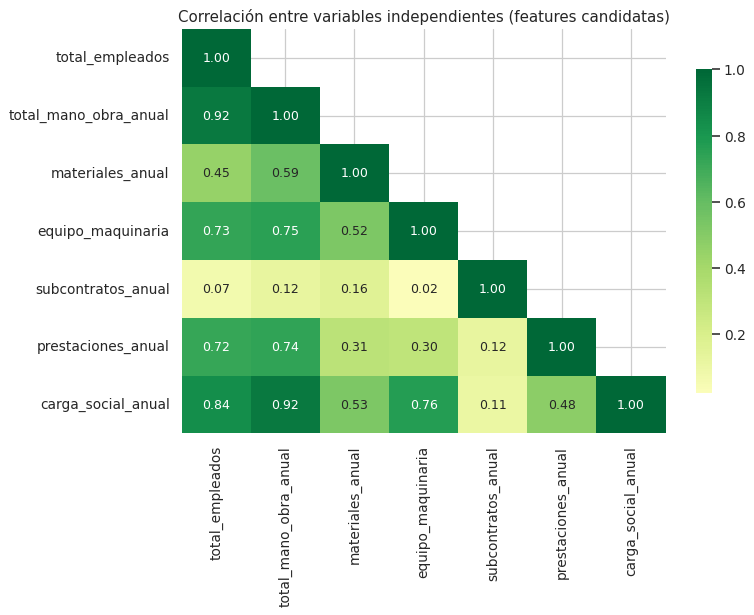

In [ ]:
# Features independientes (excluimos la variable objetivo y total_costo_servicio por data leakage)
features_indep = [
    'total_empleados', 'total_mano_obra_anual',
    'materiales_anual', 'equipo_maquinaria',
    'subcontratos_anual', 'prestaciones_anual', 'carga_social_anual'
]
features_indep = [c for c in features_indep if c in resumen_clean.columns]

corr_indep = resumen_clean[features_indep].corr()

plt.figure(figsize=(9, 7))
mask_indep = np.triu(np.ones_like(corr_indep, dtype=bool), k=1)
sns.heatmap(
    corr_indep, mask=mask_indep, cmap='RdYlGn', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlación entre variables independientes (features candidatas)')
plt.tight_layout()
plt.show()

Pares de features con |r| >= 0.60: 8
  total_empleados ↔ total_mano_obra_anual: r = 0.922
  total_empleados ↔ equipo_maquinaria: r = 0.725
  total_empleados ↔ prestaciones_anual: r = 0.722
  total_empleados ↔ carga_social_anual: r = 0.839
  total_mano_obra_anual ↔ equipo_maquinaria: r = 0.754
  total_mano_obra_anual ↔ prestaciones_anual: r = 0.739
  total_mano_obra_anual ↔ carga_social_anual: r = 0.923
  equipo_maquinaria ↔ carga_social_anual: r = 0.764


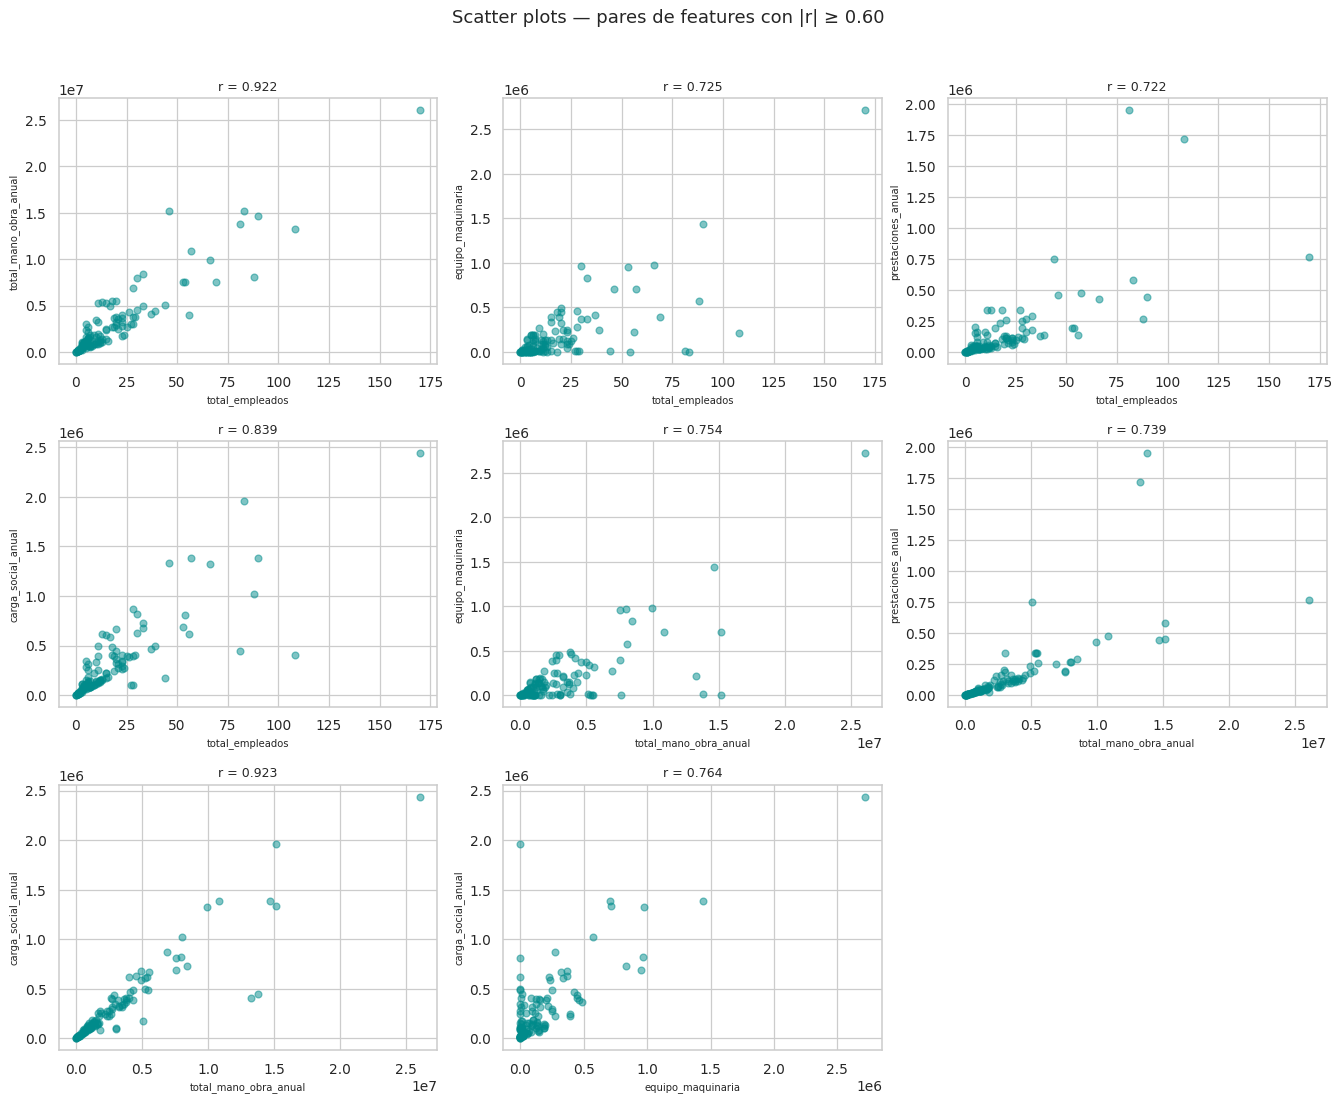

In [ ]:
# Scatter plots entre pares de features con correlación moderada-alta (|r| > 0.6)
pares_moderados = []
for i, c1 in enumerate(corr_indep.columns):
    for c2 in corr_indep.columns[i+1:]:
        r = corr_indep.loc[c1, c2]
        if abs(r) >= 0.60:
            pares_moderados.append((c1, c2, round(r, 3)))

print(f'Pares de features con |r| >= 0.60: {len(pares_moderados)}')
for c1, c2, r in pares_moderados:
    print(f'  {c1} ↔ {c2}: r = {r}')

if pares_moderados:
    n = len(pares_moderados)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()
    for idx, (c1, c2, r) in enumerate(pares_moderados):
        axes[idx].scatter(resumen_clean[c1], resumen_clean[c2], alpha=0.5, s=30, color='darkcyan')
        axes[idx].set_xlabel(c1, fontsize=8)
        axes[idx].set_ylabel(c2, fontsize=8)
        axes[idx].set_title(f'r = {r}', fontsize=10)
    for idx in range(len(pares_moderados), len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle('Scatter plots — pares de features con |r| ≥ 0.60', y=1.02)
    plt.tight_layout()
    plt.show()

**Respuesta — Pregunta 10 (correlación entre variables independientes):**

- `total_empleados` ↔ `total_mano_obra_anual` (r ≈ 0.92): altamente correlacionadas — a más empleados, mayor costo de mano de obra. Son conceptualmente distintas pero capturan información similar.
- `total_mano_obra_anual` ↔ `equipo_maquinaria` (r ≈ 0.75): proyectos con mucha mano de obra también tienden a requerir más maquinaria.
- `total_empleados` ↔ `equipo_maquinaria` (r ≈ 0.73): misma lógica operativa.
- `total_mano_obra_anual` ↔ `materiales_anual` (r ≈ 0.59): correlación moderada.
- `subcontratos_anual` tiene correlaciones bajas con todas las demás features (r < 0.20), lo que indica que captura **información independiente** no explicada por las otras variables.

**Implicación para el modelo:** aunque hay correlación entre features, ningún par supera 0.95 (umbral de multicolinealidad severa) una vez eliminadas las redundancias. Se puede proceder con todas las features seleccionadas, o considerar PCA si se busca mayor ortogonalidad.

Interpretación:
Las variables asociadas a mano de obra, prestaciones y maquinaria tienden a crecer conjuntamente debido a la naturaleza operativa de los servicios de Facility Management.

Conclusión:
No se detecta multicolinealidad severa adicional más allá de la previamente identificada en la Pregunta 7.

## 18. Detección de valores atípicos por método IQR

> **Pregunta 3 del EDA:** ¿Hay valores atípicos en el conjunto de datos?

Identificamos atípicos como observaciones fuera del intervalo $[Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR]$.

In [ ]:
def detectar_outliers_iqr(df, columnas):
    resultados = []
    for col in columnas:
        s = df[col].dropna()
        if len(s) == 0:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = s[(s < li) | (s > ls)]
        resultados.append({
            'variable': col,
            'outliers': len(outliers),
            'pct': round(len(outliers) / len(s) * 100, 2),
            'limite_inferior': round(li, 2),
            'limite_superior': round(ls, 2),
        })
    return pd.DataFrame(resultados).sort_values('pct', ascending=False)

outliers_df = detectar_outliers_iqr(resumen_clean, variables_numericas_clave)
outliers_df

,variable,outliers,pct,limite_inferior,limite_superior
4,subcontratos_anual,23,19.33,"-124,425.00","207,375.00"
9,prestaciones_anual,13,11.02,"-144,625.86","304,589.57"
0,total_empleados,12,10.08,-23.25,50.75
6,facturacion_anual,11,9.24,"-6,752,632.89","13,923,971.81"
7,costo_mano_obra_anual,10,8.47,"-2,862,097.90","6,524,084.95"
8,sueldos_salarios_anual,10,8.47,"-2,229,586.58","5,130,916.06"
2,materiales_anual,10,8.40,"-284,436.57","490,099.65"
5,total_costo_servicio,10,8.40,"-4,940,074.03","10,632,591.00"
1,total_mano_obra_anual,9,7.56,"-3,869,175.78","8,385,023.58"
3,equipo_maquinaria,9,7.56,"-298,756.97","510,398.58"


In [ ]:
# Visualizar los outliers en facturacion_anual identificando quiénes son
q1 = resumen_clean['facturacion_anual'].quantile(0.25)
q3 = resumen_clean['facturacion_anual'].quantile(0.75)
iqr = q3 - q1
ls_fact = q3 + 1.5 * iqr

outliers_fact = resumen_clean[resumen_clean['facturacion_anual'] > ls_fact][['cliente', 'facturacion_anual', 'tipo_servicio', 'total_empleados']]
print('Proyectos atípicos en facturación anual (por encima del límite IQR):')
print(outliers_fact.sort_values('facturacion_anual', ascending=False).to_string())

Proyectos atípicos en facturación anual (por encima del límite IQR):
                                           cliente  facturacion_anual        tipo_servicio  total_empleados
99                   Kenworth Mexicana S.A de C.V.      43,529,047.59             LIMPIEZA              170
29                           BMW SLP, S.A. DE C.V.      30,750,381.85  FACILITY MANAGEMENT               12
28                           BMW SLP, S.A. DE C.V.      27,990,532.56        MANTENIMIENTO               46
70   GRUPO AEROPORTUARIO DEL PACÍFICO, S.A DE C.V.      25,587,104.45             LIMPIEZA              108
72   GRUPO AEROPORTUARIO DEL PACÍFICO, S.A DE C.V.      22,578,345.33             LIMPIEZA               81
24      KELLOGG COMPANY MEXICO, S. DE R.L. DE C.V.      19,227,576.55             LIMPIEZA               90
55                             GRUPO MODELO MEXICO      18,056,725.60             LIMPIEZA               83
67                                         CUMMINS      17,988,067.

**Respuesta — Pregunta 3:**

- **Sí hay valores atípicos:** entre el 6% y 19% de las observaciones quedan fuera del rango IQR según la variable.
- `subcontratos_anual` tiene el mayor porcentaje de atípicos (19.3%) por la acumulación de ceros.
- `facturacion_anual` tiene 11 atípicos (9.24%), correspondientes a contratos industriales de gran escala: **BMW, CATERPILLAR, CUMMINS, Grupo Aeroportuario** — estos son proyectos reales y válidos para el negocio.
- **Decisión: NO se eliminan los atípicos.** Representan contratos de gran escala reales (clientes industriales), no errores de captura. Eliminarlos sesgaría el modelo hacia proyectos pequeños y lo haría inutilizable para los contratos más importantes.
- En cambio, se aplica **transformación logarítmica** para reducir el peso desproporcionado de estos valores extremos en el modelo.

### 18.1 Detección de valores atípicos — `Detalle_Empleados`

Aplicamos el mismo método IQR a las variables numéricas de la hoja de empleados.

In [ ]:
# — Detalle_Empleados — outliers por IQR
outliers_det = detectar_outliers_iqr(detalle_clean, ['num_empleados', 'importe_anual', 'importe_mensual'])
print('Atípicos por método IQR — Detalle_Empleados:')
print(outliers_det.to_string(index=False))

# Visualizar outliers de importe_anual
q1_d = detalle_clean['importe_anual'].quantile(0.25)
q3_d = detalle_clean['importe_anual'].quantile(0.75)
iqr_d = q3_d - q1_d
ls_d  = q3_d + 1.5 * iqr_d

outliers_imp = detalle_clean[detalle_clean['importe_anual'] > ls_d][[
    'categoria', 'cliente', 'importe_anual', 'num_empleados'
]].sort_values('importe_anual', ascending=False).head(10)

print('\nPartidas con importe_anual atípico (encima del límite IQR):')
print(outliers_imp.to_string(index=False))

print("""
Respuesta — Pregunta 3 (Detalle_Empleados):
• importe_anual e importe_mensual presentan ~15-20% de atípicos por IQR,
  consistente con el patrón observado en Resumen_General: unos pocos contratos
  de gran escala (muchos empleados, alto importe) elevan los límites superiores.
• num_empleados tiene atípicos correspondientes a categorías masivas
  (ej. Operario de Limpieza Diurno con 48+ empleados en contratos grandes).
• Decisión: se conservan, son datos válidos del negocio. La transformación
  log1p aplicada en sección 19.4 mitiga su impacto en el modelo.
""")

Atípicos por método IQR — Detalle_Empleados:
       variable  outliers   pct  limite_inferior  limite_superior
  num_empleados        60 13.86            -3.50             8.50
  importe_anual        41  9.47      -765,794.76     1,863,139.32
importe_mensual        41  9.47       -63,816.23       155,261.61

Partidas con importe_anual atípico (encima del límite IQR):
                 categoria                                       cliente  importe_anual  num_empleados
       TECNICO DE LIMPIEZA                 Kenworth Mexicana S.A de C.V.   9,966,509.28          69.00
    INTENDENTE DE LIMPIEZA GRUPO AEROPORTUARIO DEL PACÍFICO, S.A DE C.V.   9,693,735.48          85.00
    INTENDENTE DE LIMPIEZA    KELLOGG COMPANY MEXICO, S. DE R.L. DE C.V.   9,582,580.80          65.00
    INTENDENTE DE LIMPIEZA GRUPO AEROPORTUARIO DEL PACÍFICO, S.A DE C.V.   8,999,941.44          58.00
       TECNICO DE LIMPIEZA                                   CATERPILLAR   8,228,952.74          47.00
       TECNI

## 19. Preprocesamiento — justificación de decisiones

| Problema detectado | Estrategia aplicada | Justificación |
|---|---|---|
| `duracion_meses` contaminada y constante | Eliminación (sección 7.1) | Mezcla strings/números, varianza cero → no aporta. |
| Columnas ID/contacto (`archivo`, `rfc`, `telefono`, `domicilio`, `cp`, `numero_concurso`, etc.) | Eliminación | No aportan a la generalización; son identificadores o datos de contacto. |
| Bloque `ee_*` con faltantes en bloque | Eliminación | Faltan juntos (patrón MAR); imputar introduciría ruido. |
| Multicolinealidad severa entre variables de mano de obra | Eliminar duplicados, conservar `total_mano_obra_anual` | Tres variables tienen r > 0.98 — son la misma info en distintas secciones. |
| `facturacion_mensual` = `facturacion_anual` / 12 | Eliminación | Redundante por construcción. |
| Faltantes en numéricas (pocos, ≤1%) | Imputación con mediana | Robusta frente a distribuciones sesgadas observadas. |
| Faltantes en categóricas | Imputación con `'NO ESPECIFICADO'` | Conserva observaciones; permite que el modelo aprenda el patrón de ausencia. |
| Alta cardinalidad en `cliente`, `centro` | Agrupar categorías raras (frec. < 3) en `'OTROS'` | Reduce sobreajuste y dimensionalidad al codificar. |
| Duplicados de texto en `estado` | Normalización + mapeo manual (sección 7.3) | Pasa de 24 a 12 estados reales. |
| Sesgo positivo fuerte en variables económicas | Transformación `log1p` | Reduce sesgo, maneja ceros, mejora supuestos de modelos. |
| Atípicos en variables económicas | Se conservan | Representan proyectos de gran escala válidos para el negocio. |

### 19.1 Eliminación de columnas que no aportan al modelo

In [ ]:
df_modelo = resumen_clean.copy()

columnas_id_contacto = [
    'archivo', 'archivo_nombre', 'rfc', 'contacto', 'telefono',
    'domicilio', 'cp', 'referencia', 'numero_concurso',
    'nombre_proyecto', 'numero_oferta', 'elaboro', 'cargo_elaboro',
    'codigo_ubicacion', 'codigo_region', 'poblacion',
    # bloques redundantes/duplicados de resumen y edo
    'resumen_cliente', 'resumen_centro', 'resumen_fecha', 'resumen_servicio',
    'edo_cliente', 'edo_centro', 'edo_fecha', 'edo_proyecto', 'edo_servicio',
    # Variables multicolineales (conservamos total_mano_obra_anual como representante)
    'costo_mano_obra_anual', 'costo_mano_obra_mensual',
    'sueldos_salarios_anual',
    'facturacion_mensual', 'total_mano_obra_mensual',
    'suma_ingresos_anual', 'suma_ingresos_mensual',
    # ── Variables económicas menores (baja correlación con objetivo y/o
    #    ya capturadas en los rubros principales) ──────────────────────
    # mb_minimo_pct     : parámetro administrativo de margen mínimo, no es una
    #                     característica del proyecto → se excluye.
    # fianza_cumplimiento, seguro_rc, impuesto_nominas: costos regulatorios/fiscales
    #                     de magnitud reducida y muy baja varianza relativa → se excluyen.
    # admin_nomina_anual: subcomponente de costo_mano_obra ya eliminado → redundante.
    # uniformes, viaticos, herramienta_equipo, gasolina_lubricantes:
    #                     rubros de gasto operativo menor; su información está
    #                     contenida en total_costo_servicio y total_mano_obra_anual.
    #                     Se excluyen para evitar ruido y multicolinealidad implícita.
    'mb_minimo_pct', 'fianza_cumplimiento', 'seguro_rc', 'impuesto_nominas',
    'admin_nomina_anual', 'uniformes', 'viaticos', 'herramienta_equipo',
    'gasolina_lubricantes',
    # ── data leakage confirmado (r ≈ 0.995 con facturacion_anual) ──────
    # total_costo_servicio se excluye en 19.5; aquí no se elimina de df_modelo
    # para que quede visible en la sección de correlación (17), pero se
    # documentará su exclusión explícita en 19.5.
]

# Bloque ee_* (faltantes en bloque — patrón MAR conjunto)
columnas_ee = [c for c in df_modelo.columns if c.startswith('ee_')]
columnas_eliminar = [c for c in (columnas_id_contacto + columnas_ee) if c in df_modelo.columns]
df_modelo = df_modelo.drop(columns=columnas_eliminar)
print(f'Eliminadas {len(columnas_eliminar)} columnas. Dimensión actual: {df_modelo.shape}')
print('\nVariables que permanecen en df_modelo:')
print(list(df_modelo.columns))


Eliminadas 52 columnas. Dimensión actual: (119, 28)

Variables que permanecen en df_modelo:
['plaza', 'region', 'cliente', 'fecha_entrega', 'centro', 'estado', 'tipo_servicio', 'condiciones_pago', 'fecha_analisis', 'validez_oferta', 'vigencia_inicio', 'vigencia_fin', 'total_empleados', 'total_mano_obra_anual', 'vehiculos_anual', 'equipo_comunicacion', 'materiales_anual', 'materiales_higienicos', 'equipo_maquinaria', 'subcontratos_anual', 'mobiliario', 'total_costo_servicio', 'facturacion_anual', 'prestaciones_anual', 'carga_social_anual', 'costo_subcontratos', 'costo_materiales', 'anio_analisis']


### 19.2 Imputación de valores faltantes

In [ ]:
num_cols = df_modelo.select_dtypes(include='number').columns
cat_cols = df_modelo.select_dtypes(include='object').columns

for col in num_cols:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

for col in cat_cols:
    df_modelo[col] = df_modelo[col].fillna('NO ESPECIFICADO')

print(f'Faltantes restantes (excluyendo fechas): {df_modelo.select_dtypes(exclude="datetime").isna().sum().sum()}')

Faltantes restantes (excluyendo fechas): 0


### 19.3 Agrupación de categorías poco frecuentes

In [ ]:
def agrupar_categorias_raras(df, col, min_freq=3, etiqueta='OTROS'):
    conteos = df[col].value_counts()
    raras = conteos[conteos < min_freq].index
    df[col] = df[col].where(~df[col].isin(raras), etiqueta)
    return df

for col in ['cliente', 'centro', 'plaza', 'region', 'tipo_servicio', 'estado']:
    if col in df_modelo.columns:
        antes = df_modelo[col].nunique()
        df_modelo = agrupar_categorias_raras(df_modelo, col, min_freq=3)
        despues = df_modelo[col].nunique()
        print(f'{col}: {antes} → {despues} categorías')

cliente: 32 → 14 categorías
centro: 44 → 11 categorías
plaza: 13 → 7 categorías
region: 6 → 4 categorías
tipo_servicio: 7 → 5 categorías
estado: 13 → 9 categorías


### 19.4 Transformación logarítmica para variables sesgadas

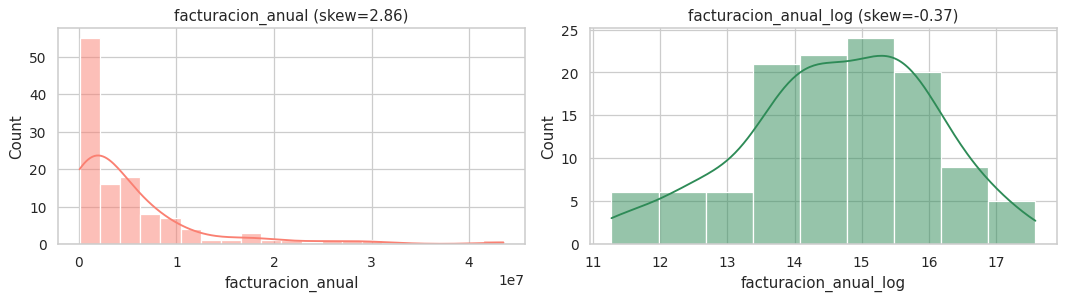


Reducción de sesgo: 2.86 → -0.37


In [ ]:
cols_log = [
    'facturacion_anual', 'total_costo_servicio',
    'total_mano_obra_anual', 'materiales_anual', 'equipo_maquinaria',
    'subcontratos_anual'
]
cols_log = [c for c in cols_log if c in df_modelo.columns]

for col in cols_log:
    df_modelo[col + '_log'] = np.log1p(df_modelo[col].clip(lower=0))

# Comparación gráfica antes/después para facturacion_anual
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
sns.histplot(df_modelo['facturacion_anual'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f'facturacion_anual (skew={df_modelo["facturacion_anual"].skew():.2f})')

sns.histplot(df_modelo['facturacion_anual_log'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'facturacion_anual_log (skew={df_modelo["facturacion_anual_log"].skew():.2f})')

plt.tight_layout()
plt.show()

print(f'\nReducción de sesgo: {df_modelo["facturacion_anual"].skew():.2f} → {df_modelo["facturacion_anual_log"].skew():.2f}')

### Interpretación

La variable `facturacion_anual` presentaba una distribución altamente asimétrica positiva (skew = 2.86), causada por la existencia de contratos industriales de gran escala.

Después de aplicar la transformación logarítmica (`log1p`), la distribución se aproxima a una forma más normal (skew = -0.37), reduciendo la influencia desproporcionada de valores extremos.

Esto mejora:
- la estabilidad estadística del modelo,
- la capacidad de generalización,
- y el desempeño de algoritmos sensibles a escalas y distribuciones sesgadas.

### 19.5 Conjunto final reducido (selección de variables relevantes)

In [ ]:
# NOTA IMPORTANTE — data leakage:
# total_costo_servicio y total_costo_servicio_log tienen r ≈ 0.995 con
# facturacion_anual por construcción contable (costo + margen = facturación).
# Incluirlos como features haría que el modelo "haga trampa": conocería el
# costo total antes de predecir la facturación.
# → Se EXCLUYEN del conjunto de features de entrenamiento.
# Se conserva en df_modelo para referencia analítica (sección 15.2 y 17),
# pero NO entra en df_final ni en ningún modelo predictivo.

variables_relevantes = [
    # ── operativas / categóricas ─────────────────────────────────────
    'total_empleados',
    'tipo_servicio', 'region', 'plaza', 'estado',
    # ── económicas originales (sin redundantes ni data leakage) ──────
    'total_mano_obra_anual',       # mejor predictor no trivial (r=0.90)
    'materiales_anual',            # r=0.61 con objetivo
    'equipo_maquinaria',           # r=0.69 con objetivo
    'subcontratos_anual',          # r=0.51; captura info independiente
    'prestaciones_anual',          # r=0.70 con objetivo
    'carga_social_anual',          # r=0.81 con objetivo
    # ── versiones log (sesgo corregido) ──────────────────────────────
    'total_mano_obra_anual_log',
    'materiales_anual_log',
    'equipo_maquinaria_log',
    'subcontratos_anual_log',
    # ── variable objetivo (original + transformada) ───────────────────
    'facturacion_anual',
    'facturacion_anual_log',
]

variables_relevantes = [c for c in variables_relevantes if c in df_modelo.columns]
df_final = df_modelo[variables_relevantes].copy()

print(f'Dimensión inicial: {resumen.shape}')
print(f'Dimensión final:   {df_final.shape}')
print(f'\nVariables en df_final:')
print(list(df_final.columns))
print('\n⚠️  total_costo_servicio EXCLUIDO por data leakage (r≈0.995 con objetivo).')
df_final.head()


Dimensión inicial: (119, 80)
Dimensión final:   (119, 17)

Variables en df_final:
['total_empleados', 'tipo_servicio', 'region', 'plaza', 'estado', 'total_mano_obra_anual', 'materiales_anual', 'equipo_maquinaria', 'subcontratos_anual', 'prestaciones_anual', 'carga_social_anual', 'total_mano_obra_anual_log', 'materiales_anual_log', 'equipo_maquinaria_log', 'subcontratos_anual_log', 'facturacion_anual', 'facturacion_anual_log']

⚠️  total_costo_servicio EXCLUIDO por data leakage (r≈0.995 con objetivo).


,total_empleados,tipo_servicio,region,plaza,estado,total_mano_obra_anual,materiales_anual,equipo_maquinaria,subcontratos_anual,prestaciones_anual,carga_social_anual,total_mano_obra_anual_log,materiales_anual_log,equipo_maquinaria_log,subcontratos_anual_log,facturacion_anual,facturacion_anual_log
0,23,LIMPIEZA,CENTRO,MEXICO,CDMX,"1,706,795.62","237,884.84","41,203.33",0.00,"57,517.53","259,493.23",14.35,12.38,10.63,0.00,"2,335,986.83",14.66
1,56,LIMPIEZA,CENTRO,MEXICO,CDMX,"4,032,512.44","283,900.86","227,979.95",0.00,"135,580.53","621,320.36",15.21,12.56,12.34,0.00,"5,351,309.20",15.49
2,16,LIMPIEZA,CENTRO,MEXICO,CDMX,"1,185,159.24","53,828.40","96,089.91",0.00,"39,954.40","180,018.54",13.99,10.89,11.47,0.00,"1,577,176.65",14.27
3,24,LIMPIEZA,CENTRO,MEXICO,CDMX,"1,822,573.95","132,928.92","87,709.33",0.00,"61,592.89","273,296.49",14.42,11.80,11.38,0.00,"2,404,701.39",14.69
4,7,LIMPIEZA,CENTRO,MEXICO,CDMX,"571,732.85","28,340.40","11,473.50",0.00,"19,463.59","82,473.56",13.26,10.25,9.35,0.00,"727,625.87",13.50


### 19.6 Correlación final con la variable objetivo transformada

In [ ]:
corr_final = df_final.select_dtypes(include='number').corr()['facturacion_anual_log']
print('Correlación de cada feature con facturacion_anual_log:')
corr_final.drop(['facturacion_anual_log', 'facturacion_anual'], errors='ignore').sort_values(ascending=False)

Correlación de cada feature con facturacion_anual_log:


,facturacion_anual_log
total_mano_obra_anual,0.74
carga_social_anual,0.70
total_empleados,0.68
total_mano_obra_anual_log,0.60
prestaciones_anual,0.55
equipo_maquinaria,0.52
equipo_maquinaria_log,0.46
materiales_anual,0.44
subcontratos_anual_log,0.41
subcontratos_anual,0.31


### 19.7 Verificación final: ya no hay multicolinealidad severa entre features

In [ ]:
# Solo features (excluimos las dos versiones de la objetivo y total_costo_servicio que es data leakage)
features_pred = [c for c in df_final.select_dtypes(include='number').columns
                 if c not in ['facturacion_anual', 'facturacion_anual_log',
                              'total_costo_servicio', 'total_costo_servicio_log']]

corr_feats = df_final[features_pred].corr()
pares_remanentes = []
for i, c1 in enumerate(corr_feats.columns):
    for c2 in corr_feats.columns[i+1:]:
        r = corr_feats.loc[c1, c2]
        if abs(r) >= 0.95:
            pares_remanentes.append({'var_1': c1, 'var_2': c2, 'r': round(r, 3)})

if pares_remanentes:
    print('Pares aún colineales:')
    print(pd.DataFrame(pares_remanentes))
else:
    print('Ya no hay pares de features con |r| >= 0.95.')

Ya no hay pares de features con |r| >= 0.95.


## 20. Análisis complementario — hoja `Detalle_Empleados`

Tipo de servicio en detalle de empleados:
tipo_servicio
LIMPIEZA                     244
MANTENIMIENTO                118
LOGISTICA                     28
SERVICIOS ADMINISTRATIVOS     21
DIRECCION DEL PROYECTO        11
FACILITY MANAGEMENT            8
JARDINERIA                     3
Name: count, dtype: int64

Top 10 categorías laborales por número de empleados (ya normalizadas):
categoria
TECNICO DE LIMPIEZA           351.00
INTENDENTE DE LIMPIEZA        324.00
OPERARIO DE LIMPIEZA DIURNO   242.00
LIMPIADOR                      57.00
AFANADOR                       57.00
INTENDENTE                     53.00
AYTE. SOPORTE A PRODUCCION     46.00
TECNICO LIMPIEZA ESPECIAL      43.00
SUPERVISOR                     42.00
OBRERO DE LIMPIEZA GENERAL     40.00
Name: num_empleados, dtype: float64


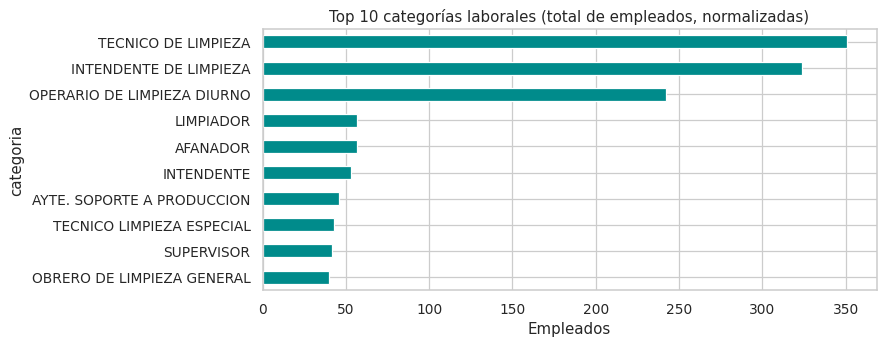

In [ ]:
print('Tipo de servicio en detalle de empleados:')
print(detalle_clean['tipo_servicio'].value_counts(dropna=False))

print('\nTop 10 categorías laborales por número de empleados (ya normalizadas):')
top_cats = detalle_clean.groupby('categoria')['num_empleados'].sum().sort_values(ascending=False).head(10)
print(top_cats)

plt.figure(figsize=(10, 4))
top_cats.plot(kind='barh', color='darkcyan')
plt.title('Top 10 categorías laborales (total de empleados, normalizadas)')
plt.xlabel('Empleados')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 21. Conclusiones del EDA

### Estructura general

- `Resumen_General` contiene **119 estudios económicos y 80 variables**; `Detalle_Empleados` complementa con 433 filas de plantilla por estudio.
- Tras el preprocesamiento, el dataset final pasa de **80 → 17 variables** relevantes y sin multicolinealidad severa, lo que reduce el riesgo de sobreajuste y facilita la interpretación del modelo.
- El conjunto de datos incluye variables **administrativas** (identificadores, fechas, contactos), **operativas** (empleados, tipo de servicio, región) y **económicas** (costos por rubro, facturación).

---

### Respuestas a las preguntas del EDA

**1. ¿Hay valores faltantes? ¿Se identifican patrones de ausencia?**  
Sí: 31 de 79 variables tienen faltantes. El bloque `ee_*` (~18%) muestra un patrón MAR conjunto — cuando una variable falta, casi todas del bloque faltan — lo que indica que esa sección no fue completada en algunos proyectos. Las variables económicas críticas tienen ≤1% de faltantes.

**2. ¿Cuáles son las estadísticas resumidas?**  
`facturacion_anual` va de ~79K a ~43.5M MXN (rango 500×). La media (5.05M) más que duplica la mediana (2.38M) en la mayoría de variables económicas, lo que confirma distribuciones muy sesgadas a la derecha.

**3. ¿Hay valores atípicos?**  
Sí, entre 6% y 19% según la variable. Los atípicos de `facturacion_anual` corresponden a contratos industriales reales (BMW, CATERPILLAR, CUMMINS, GAP) y se **conservan**; no son errores sino proyectos de gran escala válidos.

**4. ¿Cuál es la cardinalidad de las variables categóricas?**  
`cliente` (32), `centro` (43) y `archivo` (119) tienen alta cardinalidad. Las operativas útiles para el modelo tienen cardinalidad manejable: `tipo_servicio` (7→5), `region` (6→4), `plaza` (13→7) y `estado` (12→9) tras agrupar categorías raras.

**5. ¿Existen distribuciones sesgadas? ¿Se necesita transformación?**  
Sí. Todas las variables económicas tienen sesgo positivo fuerte (skewness 2.3–8.3). Se aplica `log1p`, que reduce el sesgo de `facturacion_anual` de **2.86 → -0.37** (prácticamente simétrica).

**6. ¿Se identifican tendencias temporales?**  
Sí. Los estudios cubren 2016–2022. La mediana de facturación creció de ~1.2M (2016-17) a ~5M (2021-22), un incremento de ~4× que refleja escalamiento en el tamaño de los contratos.

**7. ¿Hay correlación entre variables dependientes e independientes?**  
`total_costo_servicio` (r≈0.995) es una relación contable (data leakage). Los mejores predictores no triviales son `total_mano_obra_anual` (r≈0.90) y `total_empleados` (r≈0.83). Se detectó multicolinealidad severa en 4 pares (r>0.95), resuelta eliminando variables redundantes.

**8. ¿Cómo se distribuyen los datos por categorías?**  
MANTENIMIENTO tiene mediana de facturación ~30% mayor que LIMPIEZA. SERVICIOS ADMINISTRATIVOS es el segmento de menor escala. Por región, OCCIDENTE y CENTRO concentran el 92% de los datos con medianas similares (~2-2.3M).

**9. ¿Hay desequilibrio en la variable objetivo?**  
La variable objetivo es continua (regresión), no hay clases. Sin embargo, hay desequilibrio en la segmentación: LIMPIEZA+MANTENIMIENTO representan el 82% de los estudios. Se recomienda estratificar el split train/test por `tipo_servicio`.

**10. ¿Hay correlación entre variables independientes entre sí?**  
`total_empleados` ↔ `total_mano_obra_anual` (r≈0.92) es la correlación más alta entre features no redundantes — esperada operativamente. `subcontratos_anual` tiene correlaciones bajas con todas las demás (r<0.20), aportando información independiente. Ningún par supera el umbral de multicolinealidad severa (0.95) en el conjunto final.

---

### Problemas de calidad detectados y resueltos

1. `duracion_meses` — contaminada (mezcla strings/números) y constante tras limpiarla → **eliminada**.
2. `estado` — 24 categorías que correspondían a 12 estados reales (mayúsculas/acentos/abreviaciones) → **normalizado a 12 categorías**.
3. `categoria` en Detalle_Empleados — mismo problema de variantes de texto → **normalizado**.
4. Multicolinealidad severa en 4 pares (r>0.95) → **eliminadas las variables redundantes**, conservando una representante por bloque.
5. Variables económicas menores (`mb_minimo_pct`, `viaticos`, `uniformes`, `herramienta_equipo`, `gasolina_lubricantes`, `admin_nomina_anual`, `fianza_cumplimiento`, `seguro_rc`, `impuesto_nominas`) → **eliminadas** por baja varianza relativa o información ya contenida en los rubros principales.
6. `total_costo_servicio` y `total_costo_servicio_log` → **excluidos de `df_final`** por **data leakage** (r≈0.995 con `facturacion_anual` por relación contable directa: costo + margen = facturación).

---

### Variable objetivo recomendada

**`facturacion_anual_log`** (regresión) — versión logarítmica que corrige el sesgo y mejora los supuestos de los modelos lineales.

---


# 20. Conclusiones generales del EDA

El análisis exploratorio permitió identificar patrones relevantes en contratos industriales y de Facility Management utilizados para el desarrollo del modelo SmartPricing AI.

Hallazgos principales:
- La facturación anual presenta una fuerte relación con variables operativas como costo total del servicio, mano de obra y número de empleados.
- Existen contratos industriales de gran escala que generan distribuciones sesgadas y valores atípicos válidos para negocio.
- Se detectaron relaciones fuertes entre variables laborales, identificando posibles redundancias y riesgos de multicolinealidad.
- Las variables categóricas muestran diferencias relevantes por región y tipo de servicio.
- Las transformaciones logarítmicas redujeron significativamente el sesgo de variables económicas.

Decisiones de preprocesamiento:
- Conservación de outliers reales de negocio.
- Eliminación de variables con data leakage.
- Aplicación de transformación logarítmica.
- Manejo controlado de valores faltantes.
- Selección preliminar de variables predictoras.

Conclusión:
El dataset presenta calidad y consistencia suficientes para avanzar hacia la etapa de modelado predictivo, manteniendo representatividad del negocio real y capacidad de generalización para estimación inteligente de cotizaciones B2B.